# Signature Extraction and Manual-Signing Indicator Analysis

This notebook detects and extracts signatures, segments them, cleans them, and measures image-based indicators that may be consistent with manual signing.

## How to use this notebook

1. Run every cell in order.
2. Read the explanation above each code cell before running it.
3. Check that a cell prints its success message before continuing.
4. Do not treat the final indicators as proof that a signature is genuine or forged.

All inputs, downloaded models, intermediate artifacts, and final outputs are stored persistently in Google Drive.

In [1]:
# CELL 1 — Mount Google Drive and create persistent project folders

# Path provides a readable and platform-safe way to work with file paths.
# os is used to change the current working directory.
# sys is used to make the project importable by later notebook cells.
from google.colab import drive
from pathlib import Path
import os
import sys

# Ask Colab to connect to the user's Google Drive. Colab will display
# an authorization prompt the first time this line is executed.
drive.mount("/content/drive")

# This is the single root directory for the project. Keeping everything
# below one root makes the notebook portable and prevents scattered files.
PROJECT_DIRECTORY = Path(
    "/content/drive/MyDrive/Signature-Analysis-Project"
)

# Give each type of artifact its own named folder. Later cells will use
# these dictionary names instead of repeating long path strings.
PROJECT_PATHS = {
    "root": PROJECT_DIRECTORY,
    "inputs": PROJECT_DIRECTORY / "inputs",
    "documents": PROJECT_DIRECTORY / "inputs/documents",
    "references": PROJECT_DIRECTORY / "inputs/reference_signatures",
    "models": PROJECT_DIRECTORY / "models",
    "outputs": PROJECT_DIRECTORY / "outputs",
    "runs": PROJECT_DIRECTORY / "outputs/runs",
    "intermediate": PROJECT_DIRECTORY / "outputs/intermediate",
    "reports": PROJECT_DIRECTORY / "outputs/reports",
    "config": PROJECT_DIRECTORY / "config",
}

# Create the full folder tree. parents=True creates missing parent folders,
# while exist_ok=True makes this safe to run when folders already exist.
for folder_path in PROJECT_PATHS.values():
    folder_path.mkdir(parents=True, exist_ok=True)

# Make the project root Colab's current working directory. Relative paths
# used later will therefore resolve inside the persistent Drive project.
os.chdir(PROJECT_DIRECTORY)

# Add the project root to Python's module search path. This is useful if
# the completed project later gains reusable Python modules.
if str(PROJECT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIRECTORY))

# Fail early with a clear message if Drive did not mount. Without this
# check, later cells might accidentally write into temporary storage.
if not Path("/content/drive/MyDrive").is_dir():
    raise RuntimeError("Google Drive was not mounted successfully.")

# Confirm that every requested project folder was actually created.
missing_folders = [
    name
    for name, folder_path in PROJECT_PATHS.items()
    if not folder_path.is_dir()
]

if missing_folders:
    raise RuntimeError(
        f"These project folders could not be created: {missing_folders}"
    )

# Display the resolved paths so the student can verify where files will go.
print("Google Drive mounted successfully.")
print("Project directory:", PROJECT_DIRECTORY)
print("Current directory:", Path.cwd())

print("\nPersistent project folders:")
for name, folder_path in PROJECT_PATHS.items():
    print(f"- {name:14}: {folder_path}")

print("\nCELL 1 COMPLETED SUCCESSFULLY")

Mounted at /content/drive
Google Drive mounted successfully.
Project directory: /content/drive/MyDrive/Signature-Analysis-Project
Current directory: /content/drive/MyDrive/Signature-Analysis-Project

Persistent project folders:
- root          : /content/drive/MyDrive/Signature-Analysis-Project
- inputs        : /content/drive/MyDrive/Signature-Analysis-Project/inputs
- documents     : /content/drive/MyDrive/Signature-Analysis-Project/inputs/documents
- references    : /content/drive/MyDrive/Signature-Analysis-Project/inputs/reference_signatures
- models        : /content/drive/MyDrive/Signature-Analysis-Project/models
- outputs       : /content/drive/MyDrive/Signature-Analysis-Project/outputs
- runs          : /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs
- intermediate  : /content/drive/MyDrive/Signature-Analysis-Project/outputs/intermediate
- reports       : /content/drive/MyDrive/Signature-Analysis-Project/outputs/reports
- config        : /content/drive/MyDrive/Si

## Stage 2 — Install and verify the software environment

The pipeline combines several computer-vision tools:

- **Ultralytics YOLO** locates signatures on the document.
- **Hugging Face Transformers** loads the Segment Anything Model (SAM).
- **OpenCV** performs thresholding, morphology, line handling, and feature measurements.
- **PyMuPDF** converts PDF pages into images.
- **scikit-image** supplies skeleton, texture, and image-quality measurements.
- **ImageHash** supports later near-duplicate screening.

The first part of this cell installs the required packages. The second part imports them, reports their versions, selects a CPU or GPU, and stores the selected device in `DEVICE`. A GPU is strongly recommended for YOLO and SAM, although later OpenCV analysis runs mainly on the CPU.

> Package installation can take several minutes. Warnings from `pip` are not necessarily failures; the cell's final verification is the important result.

In [2]:
# CELL 2 — Install dependencies and verify the Colab environment

# `%pip` installs packages into the Python environment used by this notebook.
# Version ranges prevent accidental upgrades to future incompatible major releases.
%pip install -q --upgrade \
    "ultralytics>=8.3,<9" \
    "transformers>=4.45,<6" \
    "huggingface_hub>=0.25,<2" \
    "opencv-python-headless>=4.9,<5" \
    "PyMuPDF>=1.24,<2" \
    "scikit-image>=0.24,<1" \
    "ImageHash>=4.3,<5" \
    "PyYAML>=6,<7"

# Import the libraries immediately after installation. If an import fails,
# stop here and fix the environment before running later pipeline stages.
import platform

import cv2
import fitz
import imagehash
import numpy as np
import PIL
import skimage
import torch
import transformers
import ultralytics
import yaml

# PyTorch reports whether Colab has attached a CUDA-capable GPU. Later cells
# use this shared variable when moving YOLO and SAM computations to a device.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
YOLO_DEVICE = 0 if torch.cuda.is_available() else "cpu"

# Print versions to make the run reproducible and simplify troubleshooting.
print("ENVIRONMENT SUMMARY")
print("===================")
print("Python:       ", platform.python_version())
print("PyTorch:      ", torch.__version__)
print("Ultralytics:  ", ultralytics.__version__)
print("Transformers: ", transformers.__version__)
print("OpenCV:       ", cv2.__version__)
print("NumPy:        ", np.__version__)
print("scikit-image: ", skimage.__version__)
print("PyMuPDF:      ", fitz.VersionBind)
print("Pillow:       ", PIL.__version__)
print("PyYAML:       ", yaml.__version__)
print("Selected device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:           ", torch.cuda.get_device_name(0))
    print("CUDA version:  ", torch.version.cuda)
else:
    print("WARNING: No GPU is attached.")
    print("YOLO can run on the CPU, but SAM may be slow.")
    print("In Colab, select Runtime > Change runtime type > GPU if available.")

# Confirm that Cell 1 is still available. This catches runtime restarts that
# can occur after package installation or accidental out-of-order execution.
if "PROJECT_DIRECTORY" not in globals():
    raise RuntimeError("PROJECT_DIRECTORY is missing. Run Cell 1 again.")

if not PROJECT_DIRECTORY.is_dir():
    raise RuntimeError("The Google Drive project directory is unavailable.")

print("\nCELL 2 COMPLETED SUCCESSFULLY")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 138.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 77.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible

## Stage 3 — Configure the pipeline and create a run folder

This section keeps the pipeline's adjustable settings in one place. Later cells will read values from `CONFIG` instead of containing unexplained numbers.

The configuration covers document loading, Tech4Humans YOLO detection, SAM segmentation, conservative OpenCV cleaning, and image-based manual-signing indicators. It is saved to Google Drive in two places:

- A project-level YAML file that is easy to inspect.
- A JSON snapshot inside the current run folder, recording exactly which settings produced that run.

A unique UTC timestamp is used for every run so that earlier results are not overwritten. These values are prototype starting points, not universal forensic thresholds.

In [3]:
# CELL 3 — Define the configuration and create a persistent run directory

from datetime import datetime, timezone
import json

# Use only basic Python values so this dictionary can be saved safely as
# both YAML and JSON. Each section belongs to one pipeline stage.
CONFIG = {
    "project": {
        "name": "Signature Extraction and Manual-Signing Indicators",
        "random_seed": 42,
    },
    "document": {
        # PDF pages will be rendered at this resolution. Fine texture and
        # stroke-width analysis become less reliable at low resolution.
        "pdf_dpi": 300,
        "minimum_width_pixels": 600,
        "minimum_height_pixels": 600,
        "dark_brightness_limit": 35.0,
        "bright_brightness_limit": 250.0,
        "minimum_blur_variance": 80.0,
    },
    "detection": {
        # The Tech4Humans checkpoint is a YOLOv8 model trained with a
        # `signature` class. It will be downloaded in a later cell.
        "huggingface_repository": "tech4humans/yolov8s-signature-detector",
        "huggingface_filename": "yolov8s.pt",
        "local_model_filename": "tech4humans_yolov8s_signature.pt",
        "confidence_threshold": 0.25,
        "iou_threshold": 0.50,
        "inference_image_size": 1280,
        "minimum_box_area_ratio": 0.0005,
        "maximum_box_area_ratio": 0.35,
        "boundary_margin_pixels": 3,
        "crop_padding_pixels": 8,
    },
    "segmentation": {
        # SAM will receive an accepted YOLO rectangle as its box prompt.
        "model_id": "facebook/sam-vit-base",
        "minimum_mask_area_ratio": 0.01,
        "maximum_mask_area_ratio": 0.90,
        "mask_threshold": 0.0,
    },
    "cleaning": {
        # Cleaning will be conservative. If too much ink is removed, a
        # later cell will restore the uncleaned segmented signature.
        "minimum_component_area_pixels": 4,
        "adaptive_threshold_block_size": 31,
        "adaptive_threshold_constant": 11,
        "maximum_foreground_removal_ratio": 0.25,
        "horizontal_line_kernel_fraction": 0.18,
        "vertical_line_kernel_fraction": 0.18,
    },
    "analysis": {
        # Fine-grained measurements will be marked unreliable when the
        # signature crop or foreground population is too small.
        "minimum_crop_width_for_texture": 160,
        "minimum_crop_height_for_texture": 60,
        "minimum_foreground_pixels": 150,
        "local_texture_window_size": 9,
        "duplicate_hash_size": 8,
        "indicator_weights": {
            "ink_and_pressure_proxy": 0.25,
            "texture_and_grain": 0.20,
            "curvature": 0.20,
            "continuity": 0.20,
            "digital_reproduction_warning": 0.15,
        },
    },
}

# UTC timestamps are unambiguous and sort naturally by date and time.
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
RUN_DIRECTORY = PROJECT_PATHS["runs"] / RUN_ID
RUN_DIRECTORY.mkdir(parents=True, exist_ok=False)

# Save a readable project-level configuration. This file may be replaced
# by a later run, while the run-specific JSON snapshot remains unchanged.
CONFIG_PATH = PROJECT_PATHS["config"] / "pipeline_config.yaml"
with CONFIG_PATH.open("w", encoding="utf-8") as config_file:
    yaml.safe_dump(CONFIG, config_file, sort_keys=False)

RUN_CONFIG_PATH = RUN_DIRECTORY / "run_config.json"
RUN_CONFIG_PATH.write_text(
    json.dumps(CONFIG, indent=2),
    encoding="utf-8",
)

# Seed NumPy and PyTorch so repeated runs are as reproducible as practical.
np.random.seed(CONFIG["project"]["random_seed"])
torch.manual_seed(CONFIG["project"]["random_seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["project"]["random_seed"])

# Validate important settings now, producing clear errors rather than obscure
# OpenCV or scoring failures in a later stage.
block_size = CONFIG["cleaning"]["adaptive_threshold_block_size"]
if block_size < 3 or block_size % 2 == 0:
    raise ValueError("adaptive_threshold_block_size must be an odd integer >= 3.")

indicator_weight_sum = sum(
    CONFIG["analysis"]["indicator_weights"].values()
)
if not np.isclose(indicator_weight_sum, 1.0):
    raise ValueError("Manual-signing indicator weights must sum to 1.0.")

print("CONFIGURATION SUMMARY")
print("=====================")
print("Run ID:          ", RUN_ID)
print("Run directory:   ", RUN_DIRECTORY)
print("Project config:  ", CONFIG_PATH)
print("Run config copy: ", RUN_CONFIG_PATH)
print("YOLO repository: ", CONFIG["detection"]["huggingface_repository"])
print("SAM model:       ", CONFIG["segmentation"]["model_id"])
print("Weight sum:      ", indicator_weight_sum)
print("\nCELL 3 COMPLETED SUCCESSFULLY")

CONFIGURATION SUMMARY
Run ID:           20260811T153618_886744Z
Run directory:    /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z
Project config:   /content/drive/MyDrive/Signature-Analysis-Project/config/pipeline_config.yaml
Run config copy:  /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/run_config.json
YOLO repository:  tech4humans/yolov8s-signature-detector
SAM model:        facebook/sam-vit-base
Weight sum:       1.0

CELL 3 COMPLETED SUCCESSFULLY


## Stage 4 — Upload one questioned document

This stage uploads one authorized document and saves its original bytes in Google Drive. Supported inputs are PDF, PNG, JPEG, TIFF, and BMP.

Only one document is accepted per run so every output has clear provenance. The run ID is added to the stored filename, which prevents older inputs from being overwritten. For PDF input, page numbering begins at zero, so `PAGE_NUMBER = 0` selects the first page.

In [4]:
# CELL 4 — Upload and persist one questioned document

from google.colab import files

# Select the page to analyze when the input is a PDF. An ordinary image has
# only one page and must therefore use page zero.
PAGE_NUMBER = 0

# These are the formats that the next document-loading cell will decode.
SUPPORTED_DOCUMENT_EXTENSIONS = {
    ".pdf", ".png", ".jpg", ".jpeg",
    ".tif", ".tiff", ".bmp",
}

print("Select exactly one questioned document.")
uploaded_files = files.upload()

# Colab returns a dictionary of filename-to-byte-content pairs. Requiring
# exactly one entry prevents ambiguity about which input belongs to this run.
if len(uploaded_files) != 1:
    raise ValueError(
        f"Expected one document, but received {len(uploaded_files)}. "
        "Run this cell again and select exactly one file."
    )

uploaded_name, uploaded_bytes = next(iter(uploaded_files.items()))

# Discard any directory portion supplied by the browser. This ensures the
# uploaded name cannot place a file outside the intended Drive directory.
safe_original_name = Path(uploaded_name).name
file_extension = Path(safe_original_name).suffix.lower()

if file_extension not in SUPPORTED_DOCUMENT_EXTENSIONS:
    raise ValueError(
        f"Unsupported extension {file_extension!r}. Supported extensions: "
        f"{sorted(SUPPORTED_DOCUMENT_EXTENSIONS)}"
    )

if not uploaded_bytes:
    raise ValueError("The uploaded document is empty.")

# Prefix the filename with the unique run ID. write_bytes preserves the exact
# uploaded content instead of decoding and recompressing the evidence image.
DOCUMENT_PATH = (
    PROJECT_PATHS["documents"] / f"{RUN_ID}__{safe_original_name}"
)
DOCUMENT_PATH.write_bytes(uploaded_bytes)

# Save small provenance fields beside this run's outputs. The actual document
# remains in the persistent input folder referenced by stored_path.
INPUT_METADATA = {
    "original_filename": safe_original_name,
    "stored_filename": DOCUMENT_PATH.name,
    "stored_path": str(DOCUMENT_PATH),
    "file_extension": file_extension,
    "file_size_bytes": len(uploaded_bytes),
    "selected_page_number": PAGE_NUMBER,
}

INPUT_METADATA_PATH = RUN_DIRECTORY / "input_metadata.json"
INPUT_METADATA_PATH.write_text(
    json.dumps(INPUT_METADATA, indent=2),
    encoding="utf-8",
)

# Verify that Google Drive contains all uploaded bytes before continuing.
if not DOCUMENT_PATH.is_file():
    raise OSError(f"The uploaded document was not saved: {DOCUMENT_PATH}")
if DOCUMENT_PATH.stat().st_size != len(uploaded_bytes):
    raise OSError("Saved file size does not match the uploaded file size.")

print("\nINPUT DOCUMENT SUMMARY")
print("======================")
print("Original name:  ", safe_original_name)
print("Stored path:    ", DOCUMENT_PATH)
print("File type:      ", file_extension)
print("File size:      ", DOCUMENT_PATH.stat().st_size, "bytes")
print("Selected page:  ", PAGE_NUMBER)
print("Metadata saved: ", INPUT_METADATA_PATH)
print("\nCELL 4 COMPLETED SUCCESSFULLY")

Select exactly one questioned document.


Saving Test Signed Form.png to Test Signed Form.png

INPUT DOCUMENT SUMMARY
Original name:   Test Signed Form.png
Stored path:     /content/drive/MyDrive/Signature-Analysis-Project/inputs/documents/20260811T153618_886744Z__Test Signed Form.png
File type:       .png
File size:       491727 bytes
Selected page:   0
Metadata saved:  /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/input_metadata.json

CELL 4 COMPLETED SUCCESSFULLY


## Stage 5 — Decode the document and assess image quality

This stage converts the selected PDF page or image into a standard RGB NumPy array. It retains two independent arrays: an untouched evidence image and a working copy for later detection.

The cell also measures resolution, brightness, contrast, and a Laplacian-based sharpness proxy. These checks do not improve the image or decide whether it is usable; they expose limitations that may make fine texture, ink variation, or stroke measurements unreliable.

The decoded page and a JSON quality report are saved in the current Google Drive run directory. No deskewing, thresholding, denoising, or contrast enhancement is applied at this stage because those operations could alter evidence used by later image-based indicators.

DOCUMENT SUMMARY
Source:           /content/drive/MyDrive/Signature-Analysis-Project/inputs/documents/20260811T153618_886744Z__Test Signed Form.png
Page count:       1
Selected page:    0
Image shape:      (985, 1534, 3)
Quality passed:   True
Measurements:     {'width_pixels': 1534, 'height_pixels': 985, 'mean_brightness_0_255': 243.867, 'contrast_standard_deviation': 31.121, 'laplacian_variance': 959.211}
Saved page:       /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/01_original_page.png
Quality report:   /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/document_quality.json

No document-quality warnings were generated.


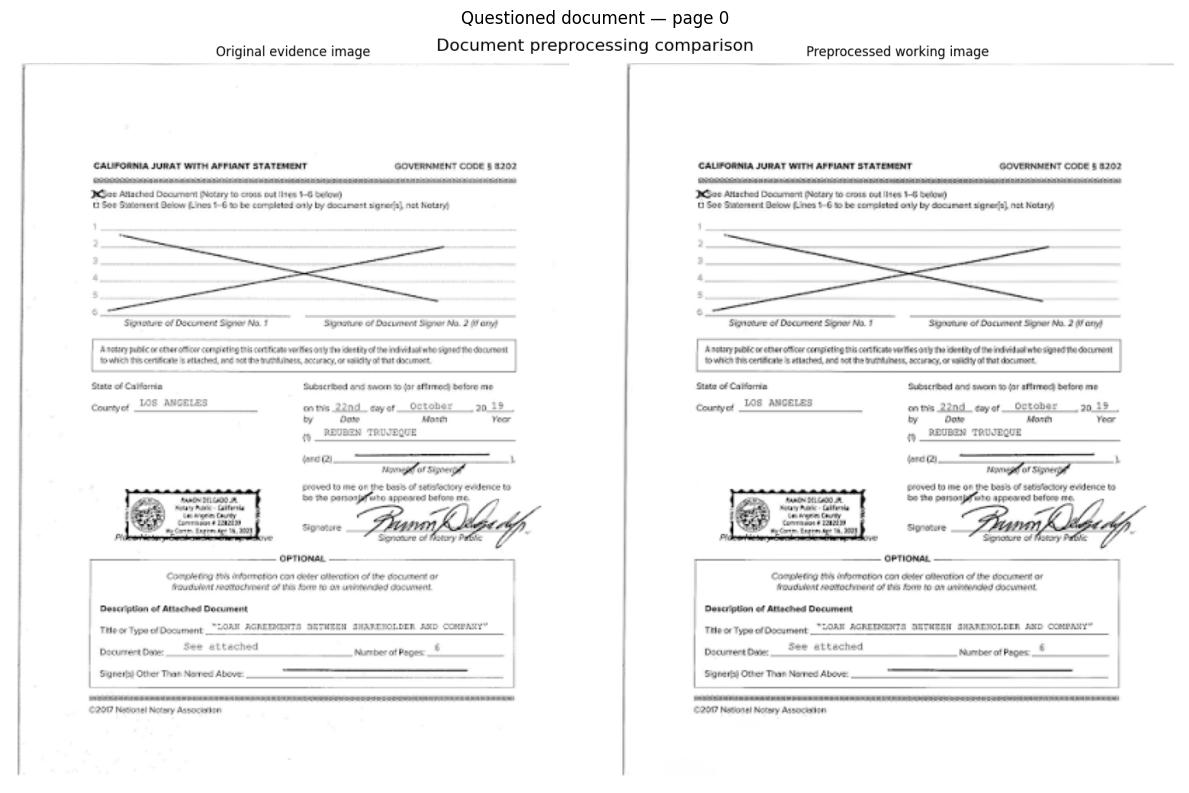

CELL 5 COMPLETED SUCCESSFULLY


In [5]:
# CELL 5 — Load the document, preserve the original, and measure quality

from io import BytesIO
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

def load_document_as_rgb(document_path, page_number, pdf_dpi):
    """Decode one image or one PDF page as an 8-bit RGB array.

    The function validates PDF page bounds and applies an image's EXIF
    orientation before converting it to RGB. It does not enhance pixels.
    """
    document_path = Path(document_path)
    extension = document_path.suffix.lower()

    if extension == ".pdf":
        # Use a context manager so the PDF file is closed after rendering.
        with fitz.open(document_path) as pdf_document:
            if pdf_document.page_count == 0:
                raise ValueError("The PDF contains no pages.")
            if not 0 <= page_number < pdf_document.page_count:
                raise IndexError(
                    f"PDF page {page_number} is outside the valid range "
                    f"0 to {pdf_document.page_count - 1}."
                )

            page = pdf_document.load_page(page_number)
            # PyMuPDF uses 72 DPI as its base coordinate resolution.
            scale = float(pdf_dpi) / 72.0
            pixmap = page.get_pixmap(
                matrix=fitz.Matrix(scale, scale),
                colorspace=fitz.csRGB,
                alpha=False,
            )
            image_rgb = np.frombuffer(pixmap.samples, dtype=np.uint8)
            image_rgb = image_rgb.reshape(pixmap.height, pixmap.width, 3)
            page_count = pdf_document.page_count
    else:
        # Pillow handles common image formats and respects camera/scanner EXIF
        # orientation. BytesIO avoids creating an extra temporary disk file.
        try:
            with Image.open(BytesIO(document_path.read_bytes())) as image:
                image = ImageOps.exif_transpose(image)
                image_rgb = np.asarray(image.convert("RGB"), dtype=np.uint8)
        except Exception as error:
            raise ValueError(
                f"The uploaded image could not be decoded: {error}"
            ) from error
        page_count = 1

    if image_rgb.ndim != 3 or image_rgb.shape[2] != 3:
        raise ValueError(f"Expected an RGB image, received shape {image_rgb.shape}.")
    if image_rgb.size == 0:
        raise ValueError("The decoded document page is empty.")

    # ascontiguousarray makes the memory layout predictable for OpenCV and
    # model libraries. copy() ensures ownership is independent of PDF buffers.
    return np.ascontiguousarray(image_rgb).copy(), page_count


def assess_document_quality(image_rgb, quality_config):
    """Return transparent acquisition-quality measurements and warnings."""
    height, width = image_rgb.shape[:2]
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    mean_brightness = float(np.mean(gray))
    contrast_standard_deviation = float(np.std(gray))
    # Variance of the Laplacian is a common sharpness proxy. It is influenced
    # by document text and noise, so it must not be interpreted in isolation.
    blur_variance = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    checks = {
        "resolution_adequate": (
            width >= quality_config["minimum_width_pixels"]
            and height >= quality_config["minimum_height_pixels"]
        ),
        "not_too_dark": mean_brightness >= quality_config["dark_brightness_limit"],
        "not_too_bright": mean_brightness <= quality_config["bright_brightness_limit"],
        "sharpness_adequate": blur_variance >= quality_config["minimum_blur_variance"],
    }

    warning_messages = {
        "resolution_adequate": "Resolution is low; fine stroke and texture measurements may be unreliable.",
        "not_too_dark": "The page is very dark and may hide ink/background separation.",
        "not_too_bright": "The page is very bright and faint strokes may be clipped.",
        "sharpness_adequate": "The page may be blurred; edge and grain measurements may be unreliable.",
    }
    warnings = [message for name, message in warning_messages.items() if not checks[name]]

    return {
        "passed": all(checks.values()),
        "measurements": {
            "width_pixels": int(width),
            "height_pixels": int(height),
            "mean_brightness_0_255": round(mean_brightness, 3),
            "contrast_standard_deviation": round(contrast_standard_deviation, 3),
            "laplacian_variance": round(blur_variance, 3),
        },
        "checks": checks,
        "warnings": warnings,
    }


# Decode the selected input using the settings established in Cells 3 and 4.
ORIGINAL_IMAGE_RGB, DOCUMENT_PAGE_COUNT = load_document_as_rgb(
    DOCUMENT_PATH,
    PAGE_NUMBER,
    CONFIG["document"]["pdf_dpi"],
)

# The working copy is intentionally independent. Later processing can modify
# it without changing the original evidence pixels held in memory.
DETECTION_IMAGE_RGB = ORIGINAL_IMAGE_RGB.copy()
if np.shares_memory(ORIGINAL_IMAGE_RGB, DETECTION_IMAGE_RGB):
    raise RuntimeError("Original and working images unexpectedly share memory.")

DOCUMENT_QUALITY = assess_document_quality(
    ORIGINAL_IMAGE_RGB,
    CONFIG["document"],
)

# OpenCV saves BGR by convention, so convert from the notebook's RGB standard.
ORIGINAL_PAGE_PATH = RUN_DIRECTORY / "01_original_page.png"
save_succeeded = cv2.imwrite(
    str(ORIGINAL_PAGE_PATH),
    cv2.cvtColor(ORIGINAL_IMAGE_RGB, cv2.COLOR_RGB2BGR),
)
if not save_succeeded:
    raise OSError(f"Could not save decoded page: {ORIGINAL_PAGE_PATH}")

DOCUMENT_QUALITY_PATH = RUN_DIRECTORY / "document_quality.json"
DOCUMENT_QUALITY_PATH.write_text(
    json.dumps(DOCUMENT_QUALITY, indent=2),
    encoding="utf-8",
)

print("DOCUMENT SUMMARY")
print("================")
print("Source:          ", DOCUMENT_PATH)
print("Page count:      ", DOCUMENT_PAGE_COUNT)
print("Selected page:   ", PAGE_NUMBER)
print("Image shape:     ", ORIGINAL_IMAGE_RGB.shape)
print("Quality passed:  ", DOCUMENT_QUALITY["passed"])
print("Measurements:    ", DOCUMENT_QUALITY["measurements"])
print("Saved page:      ", ORIGINAL_PAGE_PATH)
print("Quality report:  ", DOCUMENT_QUALITY_PATH)

if DOCUMENT_QUALITY["warnings"]:
    print("\nQUALITY WARNINGS")
    for warning in DOCUMENT_QUALITY["warnings"]:
        print("-", warning)
else:
    print("\nNo document-quality warnings were generated.")

plt.figure(figsize=(12, 9))
plt.imshow(ORIGINAL_IMAGE_RGB)
plt.title(f"Questioned document — page {PAGE_NUMBER}")
plt.axis("off")
plt.tight_layout()
plt.show()

print("CELL 5 COMPLETED SUCCESSFULLY")

## Stage 6 — Download and validate the Tech4Humans YOLO detector

This stage obtains the signature-specific YOLOv8 checkpoint configured in Cell 3. The checkpoint is downloaded once and copied into the persistent Google Drive models folder; later runs reuse that copy.

After loading the model, the cell verifies that at least one class is named `signature`. This is important because a standard COCO YOLO checkpoint does not contain a signature class and must not be substituted for this task.

A SHA-256 checksum and model metadata are saved in the current run directory. The checksum identifies the exact checkpoint bytes used by the run, although it does not independently validate the model's training quality.

> The first execution requires internet access and may take a few minutes. Loading a model checkpoint executes deserialization logic, so checkpoints should only come from a source you have reviewed and trust.

In [9]:
# CELL 6 — Download, identify, and load the Tech4Humans YOLO model

from huggingface_hub import hf_hub_download
from huggingface_hub.errors import GatedRepoError
from ultralytics import YOLO
import getpass
import hashlib
import shutil

detection_config = CONFIG["detection"]
YOLO_MODEL_PATH = (
    PROJECT_PATHS["models"]
    / detection_config["local_model_filename"]
)

# Download only when the persistent Drive copy is absent. This repository is
# gated, so the Hugging Face account must first be granted repository access.
# getpass hides the read token so it does not appear in notebook output.
downloaded_this_run = False
if not YOLO_MODEL_PATH.is_file():
    print("This gated model requires an approved Hugging Face account.")
    hf_token = getpass.getpass("Hugging Face read token (hidden): " ).strip()
    if not hf_token:
        raise ValueError("No Hugging Face token was provided.")

    try:
        print("Downloading the Tech4Humans signature detector...")
        cached_checkpoint_path = hf_hub_download(
            repo_id=detection_config["huggingface_repository"],
            filename=detection_config["huggingface_filename"],
            token=hf_token,
        )
    except GatedRepoError as error:
        raise PermissionError(
            "This Hugging Face account has not been granted access to the "
            "Tech4Humans model. Visit "
            "https://huggingface.co/tech4humans/yolov8s-signature-detector, "
            "request or accept access, and then rerun Cell 6."
        ) from error
    finally:
        # Delete the variable after the request. The token is not written to
        # the notebook, configuration, run metadata, or Google Drive.
        del hf_token

    shutil.copy2(cached_checkpoint_path, YOLO_MODEL_PATH)
    downloaded_this_run = True
else:
    print("Reusing the YOLO checkpoint already stored in Google Drive.")

if not YOLO_MODEL_PATH.is_file() or YOLO_MODEL_PATH.stat().st_size == 0:
    raise FileNotFoundError(
        f"The YOLO checkpoint is missing or empty: {YOLO_MODEL_PATH}"
    )

# Hash the file in chunks instead of reading the entire model into memory.
sha256_hasher = hashlib.sha256()
with YOLO_MODEL_PATH.open("rb") as model_file:
    for chunk in iter(lambda: model_file.read(1024 * 1024), b""):
        sha256_hasher.update(chunk)
YOLO_MODEL_SHA256 = sha256_hasher.hexdigest()

# Ultralytics reads the architecture and class-name mapping from the checkpoint.
try:
    YOLO_MODEL = YOLO(str(YOLO_MODEL_PATH))
except Exception as error:
    raise RuntimeError(
        f"The YOLO checkpoint could not be loaded: {error}"
    ) from error

# Ultralytics normally exposes names as {class_id: class_name}. Normalize both
# dictionary and list representations before validating the signature class.
raw_class_names = YOLO_MODEL.names
if isinstance(raw_class_names, dict):
    YOLO_CLASS_NAMES = {int(key): str(value) for key, value in raw_class_names.items()}
else:
    YOLO_CLASS_NAMES = {index: str(value) for index, value in enumerate(raw_class_names)}

signature_class_ids = [
    class_id
    for class_id, class_name in YOLO_CLASS_NAMES.items()
    if class_name.strip().lower() == "signature"
]
if not signature_class_ids:
    raise ValueError(
        "The loaded YOLO model has no class named 'signature'. "
        f"Available classes: {YOLO_CLASS_NAMES}"
    )

YOLO_SIGNATURE_CLASS_IDS = signature_class_ids

YOLO_MODEL_METADATA = {
    "repository": detection_config["huggingface_repository"],
    "repository_filename": detection_config["huggingface_filename"],
    "local_path": str(YOLO_MODEL_PATH),
    "size_bytes": YOLO_MODEL_PATH.stat().st_size,
    "sha256": YOLO_MODEL_SHA256,
    "downloaded_this_run": downloaded_this_run,
    "class_names": YOLO_CLASS_NAMES,
    "signature_class_ids": YOLO_SIGNATURE_CLASS_IDS,
}

YOLO_MODEL_METADATA_PATH = RUN_DIRECTORY / "yolo_model_metadata.json"
YOLO_MODEL_METADATA_PATH.write_text(
    json.dumps(YOLO_MODEL_METADATA, indent=2),
    encoding="utf-8",
)

print("\nYOLO MODEL SUMMARY")
print("==================")
print("Repository:       ", YOLO_MODEL_METADATA["repository"])
print("Model path:       ", YOLO_MODEL_PATH)
print("Size:             ", YOLO_MODEL_PATH.stat().st_size, "bytes")
print("Downloaded now:   ", downloaded_this_run)
print("Classes:          ", YOLO_CLASS_NAMES)
print("Signature IDs:    ", YOLO_SIGNATURE_CLASS_IDS)
print("SHA-256:          ", YOLO_MODEL_SHA256)
print("Metadata saved:   ", YOLO_MODEL_METADATA_PATH)
print("\nCELL 6 COMPLETED SUCCESSFULLY")

This gated model requires an approved Hugging Face account.
Hugging Face read token (hidden): ··········


yolov8s.pt: reconstructing file:   0%|          |  0.00B / 22.5MB            

yolov8s.pt: downloading bytes:           |  0.00B            


YOLO MODEL SUMMARY
Repository:        tech4humans/yolov8s-signature-detector
Model path:        /content/drive/MyDrive/Signature-Analysis-Project/models/tech4humans_yolov8s_signature.pt
Size:              22515427 bytes
Downloaded now:    True
Classes:           {0: 'signature'}
Signature IDs:     [0]
SHA-256:           789580c242ac6f2543b4c09f083ca8c4ef6f1c598359bd2395febfcbcce99363
Metadata saved:    /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/yolo_model_metadata.json

CELL 6 COMPLETED SUCCESSFULLY


## Stage 7 — Detect signature candidates with YOLO

This stage runs the loaded Tech4Humans YOLO model on the decoded document page. It retains only detections whose model class is `signature`, clips every bounding box to the page, and extracts an unchanged crop from the original RGB image.

Each candidate receives transparent quality warnings when its box is unusually small, unusually large, or touches the page boundary. These warnings do not automatically remove a detection. All candidates are sorted by confidence and assigned stable, one-based detection numbers for the manual review stage that follows.

The annotated page, individual candidate crops, and JSON-safe detection metadata are saved in the current Google Drive run directory. YOLO only localizes signature-like regions; it does not establish that a mark is handwritten, genuine, or associated with a particular person.

/tmp/ipykernel_1107/2806733930.py:63: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  yolo_input = Image.fromarray(DETECTION_IMAGE_RGB, mode="RGB")


YOLO DETECTION SUMMARY
Signature candidates: 5
#1: confidence=0.845, box=[1243, 610, 1489, 676], quality_passed=True
#2: confidence=0.828, box=[453, 610, 699, 677], quality_passed=True
#3: confidence=0.582, box=[117, 266, 589, 358], quality_passed=True
#4: confidence=0.556, box=[913, 269, 1377, 355], quality_passed=True
#5: confidence=0.354, box=[450, 556, 607, 586], quality_passed=True


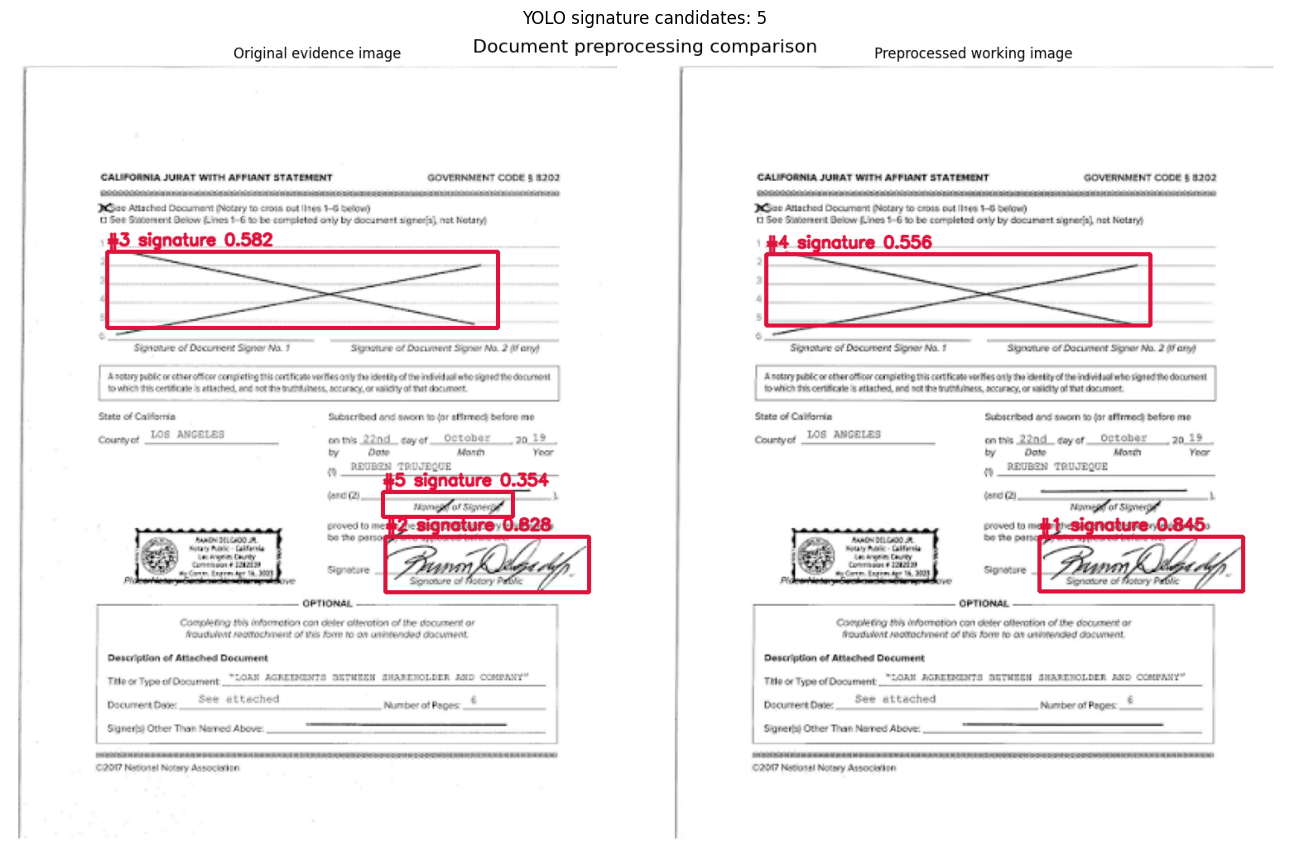

Annotated page:     /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/detections/yolo_annotated_page.png
Detection metadata: /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/detections/detections.json

CELL 7 COMPLETED SUCCESSFULLY


In [10]:
# CELL 7 — Run YOLO and preserve all signature candidates

import math

def clip_box_to_image(box_xyxy, image_width, image_height):
    """Convert a floating-point YOLO box to safe integer pixel bounds."""
    x1, y1, x2, y2 = [float(value) for value in box_xyxy]
    # Floor the upper-left and ceil the lower-right so edge pixels predicted
    # by the model are not accidentally discarded during integer conversion.
    x1 = max(0, min(image_width - 1, math.floor(x1)))
    y1 = max(0, min(image_height - 1, math.floor(y1)))
    x2 = max(1, min(image_width, math.ceil(x2)))
    y2 = max(1, min(image_height, math.ceil(y2)))
    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Degenerate detection box after clipping: {[x1, y1, x2, y2]}")
    return [int(x1), int(y1), int(x2), int(y2)]


def expand_box(box_xyxy, padding, image_width, image_height):
    """Add context around a detection without crossing image boundaries."""
    x1, y1, x2, y2 = box_xyxy
    return [
        max(0, x1 - padding),
        max(0, y1 - padding),
        min(image_width, x2 + padding),
        min(image_height, y2 + padding),
    ]


def evaluate_detection_box(box_xyxy, image_width, image_height, config):
    """Describe geometric quality without deciding whether a box is valid."""
    x1, y1, x2, y2 = box_xyxy
    box_area = (x2 - x1) * (y2 - y1)
    page_area = max(image_width * image_height, 1)
    area_ratio = box_area / page_area
    margin = int(config["boundary_margin_pixels"])
    touches_boundary = (
        x1 <= margin
        or y1 <= margin
        or x2 >= image_width - margin
        or y2 >= image_height - margin
    )

    warnings = []
    if area_ratio < config["minimum_box_area_ratio"]:
        warnings.append("Bounding box is unusually small relative to the page.")
    if area_ratio > config["maximum_box_area_ratio"]:
        warnings.append("Bounding box is unusually large relative to the page.")
    if touches_boundary:
        warnings.append("Bounding box touches the page boundary and may be incomplete.")

    return {
        "passed": len(warnings) == 0,
        "box_area_pixels": int(box_area),
        "box_area_ratio": round(float(area_ratio), 6),
        "touches_boundary": bool(touches_boundary),
        "warnings": warnings,
    }


# A PIL image explicitly communicates RGB channel order to Ultralytics. Passing
# a NumPy array could be interpreted as an OpenCV-style BGR source.
yolo_input = Image.fromarray(DETECTION_IMAGE_RGB, mode="RGB")

YOLO_RAW_RESULTS = YOLO_MODEL.predict(
    source=yolo_input,
    conf=detection_config["confidence_threshold"],
    iou=detection_config["iou_threshold"],
    imgsz=detection_config["inference_image_size"],
    device=YOLO_DEVICE,
    verbose=False,
)

if len(YOLO_RAW_RESULTS) != 1:
    raise RuntimeError(f"Expected one YOLO result, received {len(YOLO_RAW_RESULTS)}.")

page_height, page_width = ORIGINAL_IMAGE_RGB.shape[:2]
raw_result = YOLO_RAW_RESULTS[0]
SIGNATURE_DETECTIONS = []

if raw_result.boxes is not None:
    raw_boxes = raw_result.boxes.xyxy.detach().cpu().numpy()
    raw_confidences = raw_result.boxes.conf.detach().cpu().numpy()
    raw_class_ids = raw_result.boxes.cls.detach().cpu().numpy().astype(int)

    for raw_box, confidence, class_id in zip(
        raw_boxes, raw_confidences, raw_class_ids
    ):
        # Ignore any unexpected non-signature class even if the checkpoint is
        # later replaced by a multi-class signature/document detector.
        if int(class_id) not in YOLO_SIGNATURE_CLASS_IDS:
            continue

        box_xyxy = clip_box_to_image(raw_box, page_width, page_height)
        padded_box_xyxy = expand_box(
            box_xyxy,
            int(detection_config["crop_padding_pixels"]),
            page_width,
            page_height,
        )
        px1, py1, px2, py2 = padded_box_xyxy
        crop_rgb = ORIGINAL_IMAGE_RGB[py1:py2, px1:px2].copy()
        if crop_rgb.size == 0:
            continue

        SIGNATURE_DETECTIONS.append({
            "class_id": int(class_id),
            "class_name": YOLO_CLASS_NAMES[int(class_id)],
            "confidence": round(float(confidence), 6),
            "bbox_xyxy": box_xyxy,
            "padded_bbox_xyxy": padded_box_xyxy,
            "crop_rgb": crop_rgb,
            "quality": evaluate_detection_box(
                box_xyxy, page_width, page_height, detection_config
            ),
        })

# Sorting makes detection number 1 consistently refer to the highest-confidence
# candidate, independent of the model's internal output order.
SIGNATURE_DETECTIONS.sort(key=lambda item: item["confidence"], reverse=True)
for detection_number, detection in enumerate(SIGNATURE_DETECTIONS, start=1):
    detection["detection_number"] = detection_number

# Draw on a copy; ORIGINAL_IMAGE_RGB remains unchanged. Coordinates use the
# unpadded detection box while saved crops include the configured context.
YOLO_ANNOTATED_IMAGE_RGB = ORIGINAL_IMAGE_RGB.copy()
for detection in SIGNATURE_DETECTIONS:
    x1, y1, x2, y2 = detection["bbox_xyxy"]
    label = f"#{detection['detection_number']} signature {detection['confidence']:.3f}"
    cv2.rectangle(YOLO_ANNOTATED_IMAGE_RGB, (x1, y1), (x2, y2), (220, 20, 60), 3)
    label_y = max(20, y1 - 8)
    cv2.putText(
        YOLO_ANNOTATED_IMAGE_RGB, label, (x1, label_y),
        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (220, 20, 60), 2, cv2.LINE_AA,
    )

DETECTION_OUTPUT_DIRECTORY = RUN_DIRECTORY / "detections"
DETECTION_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
ANNOTATED_DETECTION_PATH = DETECTION_OUTPUT_DIRECTORY / "yolo_annotated_page.png"
if not cv2.imwrite(
    str(ANNOTATED_DETECTION_PATH),
    cv2.cvtColor(YOLO_ANNOTATED_IMAGE_RGB, cv2.COLOR_RGB2BGR),
):
    raise OSError(f"Could not save {ANNOTATED_DETECTION_PATH}")

# Image arrays cannot be serialized to JSON. Save each crop as PNG and replace
# the in-memory array with its path in the metadata representation.
detection_metadata = []
for detection in SIGNATURE_DETECTIONS:
    crop_path = DETECTION_OUTPUT_DIRECTORY / (
        f"candidate_{detection['detection_number']:02d}.png"
    )
    if not cv2.imwrite(
        str(crop_path),
        cv2.cvtColor(detection["crop_rgb"], cv2.COLOR_RGB2BGR),
    ):
        raise OSError(f"Could not save {crop_path}")
    detection["crop_path"] = crop_path
    detection_metadata.append({
        key: (str(value) if isinstance(value, Path) else value)
        for key, value in detection.items()
        if key != "crop_rgb"
    })

DETECTION_METADATA_PATH = DETECTION_OUTPUT_DIRECTORY / "detections.json"
DETECTION_METADATA_PATH.write_text(
    json.dumps({
        "signature_detected": bool(SIGNATURE_DETECTIONS),
        "detection_count": len(SIGNATURE_DETECTIONS),
        "detections": detection_metadata,
    }, indent=2),
    encoding="utf-8",
)

print("YOLO DETECTION SUMMARY")
print("======================")
print("Signature candidates:", len(SIGNATURE_DETECTIONS))
for detection in SIGNATURE_DETECTIONS:
    print(
        f"#{detection['detection_number']}: "
        f"confidence={detection['confidence']:.3f}, "
        f"box={detection['bbox_xyxy']}, "
        f"quality_passed={detection['quality']['passed']}"
    )
    for warning in detection["quality"]["warnings"]:
        print("   warning:", warning)

if not SIGNATURE_DETECTIONS:
    print("WARNING: No signature candidate met the configured confidence threshold.")

plt.figure(figsize=(13, 10))
plt.imshow(YOLO_ANNOTATED_IMAGE_RGB)
plt.title(f"YOLO signature candidates: {len(SIGNATURE_DETECTIONS)}")
plt.axis("off")
plt.tight_layout()
plt.show()

print("Annotated page:    ", ANNOTATED_DETECTION_PATH)
print("Detection metadata:", DETECTION_METADATA_PATH)
print("\nCELL 7 COMPLETED SUCCESSFULLY")

## Stage 8 — Review and accept the correct YOLO candidates

YOLO can confuse handwritten notes, stamps, logos, or other dark marks with signatures. Before segmentation, this stage displays every candidate and requires an explicit list of accepted detection numbers.

Edit `ACCEPTED_DETECTION_NUMBERS` in the code cell after looking at the numbered crops. For example, use `[1]` to accept only candidate 1 or `[1, 3]` to accept candidates 1 and 3. Use an empty list only when none of the candidates is a signature.

The default `[1]` assumes the highest-confidence candidate is correct, but confidence is not proof. The selection and all rejections are stored in a JSON review record in Google Drive. SAM will process only accepted candidates.

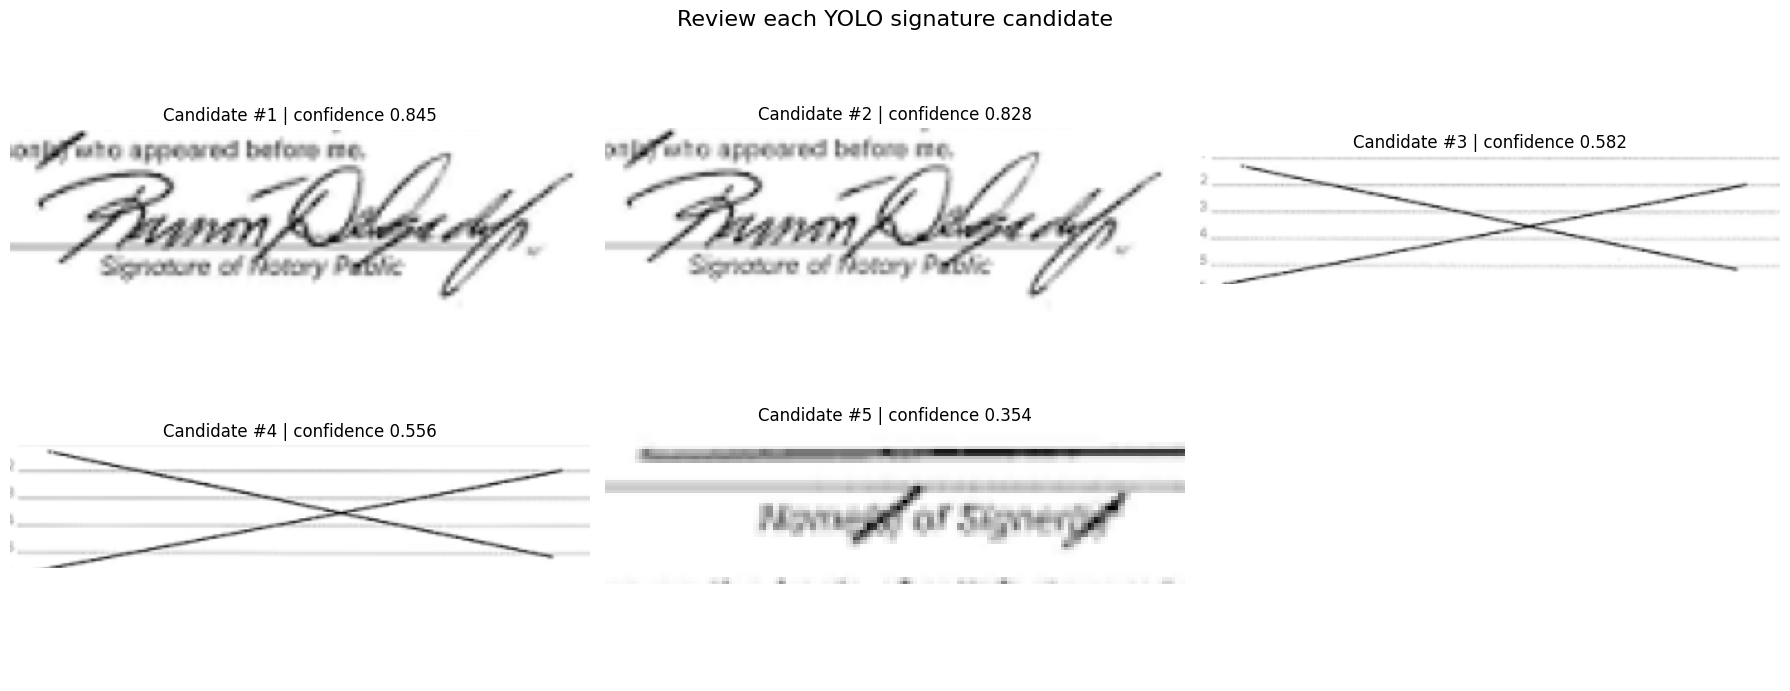

HUMAN REVIEW SUMMARY
Available candidates: [1, 2, 3, 4, 5]
Accepted candidates:  [1]
Accepted count:       1
Rejected count:       4
Review saved:         /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/detections/human_review.json
Accepted candidates are ready for SAM segmentation.

CELL 8 COMPLETED SUCCESSFULLY


In [11]:
# CELL 8 — Display candidates and record the human selection

# IMPORTANT: Inspect the displayed candidates and edit this list when needed.
# Detection numbers are the red numbers drawn by Cell 7.
ACCEPTED_DETECTION_NUMBERS = [1]

if not SIGNATURE_DETECTIONS:
    raise ValueError(
        "There are no YOLO candidates to review. Consider checking the input "
        "page or lowering the confidence threshold in Cell 3, then rerun Cells 3–7."
    )

# Display candidates in a compact grid. A maximum of three columns keeps small
# signature crops large enough to inspect in a typical Colab window.
candidate_count = len(SIGNATURE_DETECTIONS)
column_count = min(3, candidate_count)
row_count = math.ceil(candidate_count / column_count)
figure, axes = plt.subplots(
    row_count,
    column_count,
    figsize=(6 * column_count, 3.5 * row_count),
    squeeze=False,
)

for axis in axes.flat:
    axis.axis("off")

for axis, detection in zip(axes.flat, SIGNATURE_DETECTIONS):
    axis.imshow(detection["crop_rgb"])
    axis.set_title(
        f"Candidate #{detection['detection_number']} | "
        f"confidence {detection['confidence']:.3f}"
    )
    axis.axis("off")

figure.suptitle("Review each YOLO signature candidate", fontsize=16)
figure.tight_layout()
plt.show()

# Normalize the user's list and reject ambiguous values such as booleans,
# duplicates, zero, negative numbers, or candidate numbers that do not exist.
if not isinstance(ACCEPTED_DETECTION_NUMBERS, list):
    raise TypeError("ACCEPTED_DETECTION_NUMBERS must be a Python list.")
if any(type(number) is not int for number in ACCEPTED_DETECTION_NUMBERS):
    raise TypeError("Every accepted detection number must be an integer.")
if len(set(ACCEPTED_DETECTION_NUMBERS)) != len(ACCEPTED_DETECTION_NUMBERS):
    raise ValueError("ACCEPTED_DETECTION_NUMBERS contains duplicates.")

available_detection_numbers = {
    detection["detection_number"] for detection in SIGNATURE_DETECTIONS
}
unknown_numbers = sorted(
    set(ACCEPTED_DETECTION_NUMBERS) - available_detection_numbers
)
if unknown_numbers:
    raise ValueError(
        f"Unknown detection numbers: {unknown_numbers}. "
        f"Available numbers are: {sorted(available_detection_numbers)}"
    )

accepted_number_set = set(ACCEPTED_DETECTION_NUMBERS)
ACCEPTED_DETECTIONS = []
REJECTED_DETECTIONS = []

for detection in SIGNATURE_DETECTIONS:
    # copy() creates an independent dictionary, while crop_rgb continues to
    # reference immutable source pixels that this review stage never modifies.
    reviewed_detection = detection.copy()
    accepted = detection["detection_number"] in accepted_number_set
    reviewed_detection["human_review"] = {
        "accepted": accepted,
        "review_method": "explicit_detection_number_selection",
    }
    if accepted:
        ACCEPTED_DETECTIONS.append(reviewed_detection)
    else:
        REJECTED_DETECTIONS.append(reviewed_detection)

# Store only JSON-compatible review data; image arrays remain in memory and
# their previously saved crop paths are recorded in the review artifact.
review_records = []
for detection in ACCEPTED_DETECTIONS + REJECTED_DETECTIONS:
    review_records.append({
        "detection_number": detection["detection_number"],
        "accepted": detection["human_review"]["accepted"],
        "confidence": detection["confidence"],
        "bbox_xyxy": detection["bbox_xyxy"],
        "padded_bbox_xyxy": detection["padded_bbox_xyxy"],
        "crop_path": str(detection["crop_path"]),
        "quality": detection["quality"],
    })
review_records.sort(key=lambda item: item["detection_number"])

DETECTION_REVIEW_PATH = DETECTION_OUTPUT_DIRECTORY / "human_review.json"
DETECTION_REVIEW_PATH.write_text(
    json.dumps({
        "accepted_detection_numbers": sorted(ACCEPTED_DETECTION_NUMBERS),
        "accepted_count": len(ACCEPTED_DETECTIONS),
        "rejected_count": len(REJECTED_DETECTIONS),
        "records": review_records,
    }, indent=2),
    encoding="utf-8",
)

print("HUMAN REVIEW SUMMARY")
print("====================")
print("Available candidates:", sorted(available_detection_numbers))
print("Accepted candidates: ", sorted(ACCEPTED_DETECTION_NUMBERS))
print("Accepted count:      ", len(ACCEPTED_DETECTIONS))
print("Rejected count:      ", len(REJECTED_DETECTIONS))
print("Review saved:        ", DETECTION_REVIEW_PATH)

if not ACCEPTED_DETECTIONS:
    print("WARNING: No candidate was accepted. SAM segmentation cannot continue.")
else:
    print("Accepted candidates are ready for SAM segmentation.")

print("\nCELL 8 COMPLETED SUCCESSFULLY")

## Stage 9 — Load the Segment Anything Model (SAM)

YOLO provides rectangular signature locations, but those rectangles may also contain paper background, printed lines, labels, or nearby text. SAM uses each accepted YOLO rectangle as a box prompt and predicts a foreground mask within that region.

This cell downloads the configured SAM model and processor into a persistent Hugging Face cache inside the Google Drive models folder. A GPU uses half-precision weights to reduce memory consumption; a CPU uses full precision for compatibility.

Loading SAM is kept separate from segmentation so model-download or memory problems can be diagnosed before processing candidates. SAM is a general segmentation model, not a signature-authenticity model, and its mask must still be quality-checked.

In [12]:
# CELL 9 — Download and load SAM from the persistent Drive model cache

from transformers import SamModel, SamProcessor

if not ACCEPTED_DETECTIONS:
    raise ValueError(
        "No signature candidate was accepted in Cell 8. "
        "Accept at least one correct candidate before loading SAM."
    )

segmentation_config = CONFIG["segmentation"]
SAM_MODEL_ID = segmentation_config["model_id"]
SAM_CACHE_DIRECTORY = PROJECT_PATHS["models"] / "huggingface_cache"
SAM_CACHE_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Float16 substantially reduces GPU memory use. Most CPU operations do not
# support float16 efficiently, so CPU execution retains float32 weights.
SAM_DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

print("Loading the SAM processor...")
try:
    SAM_PROCESSOR = SamProcessor.from_pretrained(
        SAM_MODEL_ID,
        cache_dir=str(SAM_CACHE_DIRECTORY),
    )
except Exception as error:
    raise RuntimeError(f"Could not load the SAM processor: {error}") from error

print("Loading the SAM model...")
try:
    SAM_MODEL = SamModel.from_pretrained(
        SAM_MODEL_ID,
        cache_dir=str(SAM_CACHE_DIRECTORY),
        torch_dtype=SAM_DTYPE,
    )
    SAM_MODEL.to(DEVICE)
    SAM_MODEL.eval()
except RuntimeError as error:
    if "out of memory" in str(error).lower():
        raise RuntimeError(
            "SAM could not fit in the selected device memory. Restart the "
            "runtime, select a GPU if available, and rerun the notebook."
        ) from error
    raise
except Exception as error:
    raise RuntimeError(f"Could not load the SAM model: {error}") from error

# Record configuration rather than the entire model object. The downloaded
# checkpoint files remain in the persistent cache directory.
SAM_MODEL_METADATA = {
    "model_id": SAM_MODEL_ID,
    "cache_directory": str(SAM_CACHE_DIRECTORY),
    "device": DEVICE,
    "dtype": str(SAM_DTYPE),
    "accepted_detection_count": len(ACCEPTED_DETECTIONS),
    "model_class": SAM_MODEL.__class__.__name__,
    "processor_class": SAM_PROCESSOR.__class__.__name__,
}

SAM_MODEL_METADATA_PATH = RUN_DIRECTORY / "sam_model_metadata.json"
SAM_MODEL_METADATA_PATH.write_text(
    json.dumps(SAM_MODEL_METADATA, indent=2),
    encoding="utf-8",
)

print("\nSAM MODEL SUMMARY")
print("=================")
print("Model ID:            ", SAM_MODEL_ID)
print("Model class:         ", SAM_MODEL.__class__.__name__)
print("Processor class:     ", SAM_PROCESSOR.__class__.__name__)
print("Device:              ", DEVICE)
print("Data type:           ", SAM_DTYPE)
print("Persistent cache:    ", SAM_CACHE_DIRECTORY)
print("Accepted candidates:", len(ACCEPTED_DETECTIONS))
print("Metadata saved:      ", SAM_MODEL_METADATA_PATH)
print("\nCELL 9 COMPLETED SUCCESSFULLY")

Loading the SAM processor...


preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

Loading the SAM model...


config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]


SAM MODEL SUMMARY
Model ID:             facebook/sam-vit-base
Model class:          SamModel
Processor class:      SamProcessor
Device:               cuda
Data type:            torch.float16
Persistent cache:     /content/drive/MyDrive/Signature-Analysis-Project/models/huggingface_cache
Accepted candidates: 1
Metadata saved:       /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/sam_model_metadata.json

CELL 9 COMPLETED SUCCESSFULLY


## Stage 10 — Segment accepted signature candidates with SAM

This stage sends the full document image and all accepted YOLO rectangles to SAM in one inference call. SAM normally returns three possible masks per box. The notebook prefers the highest predicted-IoU mask whose area is within the configured plausible range; if none is plausible, it retains the highest-IoU mask and issues quality warnings.

For every accepted candidate, the stage stores a full-page boolean mask in memory and saves three reviewer-friendly artifacts to Google Drive: a cropped binary mask, a white-background segmented crop, and a page overlay.

Mask quality is evaluated relative to the accepted YOLO rectangle, not the entire document. A passing mask still requires visual review because thin handwriting, printed lines, and nearby text are difficult general-purpose segmentation cases.

/tmp/ipykernel_1107/3090559357.py:45: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  images=Image.fromarray(ORIGINAL_IMAGE_RGB, mode="RGB"),


SAM SEGMENTATION SUMMARY
Candidate #1: mask=0, predicted_iou=0.894, area_ratio=0.581, quality_passed=False


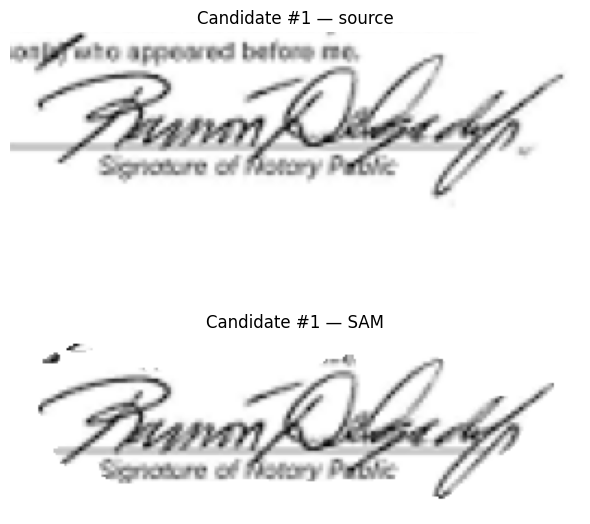

Segmentation metadata: /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/segmentation/segmentation_results.json

CELL 10 COMPLETED SUCCESSFULLY


In [13]:
# CELL 10 — Segment accepted YOLO boxes with SAM and save mask evidence

def assess_sam_mask(mask, detection_box, segmentation_settings):
    """Measure how much of a YOLO box is occupied by a SAM mask."""
    x1, y1, x2, y2 = detection_box
    box_mask = mask[y1:y2, x1:x2]
    box_area = max((x2 - x1) * (y2 - y1), 1)
    mask_pixels_inside_box = int(np.count_nonzero(box_mask))
    mask_area_ratio = mask_pixels_inside_box / box_area

    touches_box_boundary = bool(
        box_mask.size > 0
        and (
            np.any(box_mask[0, :])
            or np.any(box_mask[-1, :])
            or np.any(box_mask[:, 0])
            or np.any(box_mask[:, -1])
        )
    )

    warnings = []
    if mask_area_ratio < segmentation_settings["minimum_mask_area_ratio"]:
        warnings.append("SAM mask is unusually small inside the YOLO box.")
    if mask_area_ratio > segmentation_settings["maximum_mask_area_ratio"]:
        warnings.append("SAM mask fills most of the YOLO box and may represent background.")
    if touches_box_boundary:
        warnings.append("SAM mask touches the YOLO-box boundary and may be incomplete.")

    return {
        "passed": len(warnings) == 0,
        "mask_pixels_inside_box": mask_pixels_inside_box,
        "mask_area_ratio_inside_box": round(float(mask_area_ratio), 6),
        "touches_box_boundary": touches_box_boundary,
        "warnings": warnings,
    }


# SAM expects one outer list per input image and one inner list containing the
# boxes for that image. Coordinates refer to the full original image.
sam_prompt_boxes = [[
    detection["bbox_xyxy"] for detection in ACCEPTED_DETECTIONS
]]

sam_inputs = SAM_PROCESSOR(
    images=Image.fromarray(ORIGINAL_IMAGE_RGB, mode="RGB"),
    input_boxes=sam_prompt_boxes,
    return_tensors="pt",
)

# Move every tensor to the selected device. Only pixel values follow the model
# dtype; box coordinates and size tensors retain their processor-created types.
sam_inputs = {key: value.to(DEVICE) for key, value in sam_inputs.items()}
sam_inputs["pixel_values"] = sam_inputs["pixel_values"].to(dtype=SAM_DTYPE)

with torch.inference_mode():
    sam_outputs = SAM_MODEL(**sam_inputs, multimask_output=True)

# Resize predicted masks from SAM's internal resolution back to the exact
# original page dimensions. The result for one image has shape B x 3 x H x W,
# where B is the number of prompted boxes and 3 is the candidate-mask count.
post_processed_masks = SAM_PROCESSOR.image_processor.post_process_masks(
    sam_outputs.pred_masks.detach().cpu(),
    sam_inputs["original_sizes"].detach().cpu(),
    sam_inputs["reshaped_input_sizes"].detach().cpu(),
    mask_threshold=float(segmentation_config["mask_threshold"]),
    binarize=True,
)

candidate_masks_for_image = post_processed_masks[0].numpy().astype(bool)
predicted_iou_scores = sam_outputs.iou_scores.detach().float().cpu().numpy()[0]

if candidate_masks_for_image.shape[0] != len(ACCEPTED_DETECTIONS):
    raise RuntimeError(
        "SAM returned a different number of box results than were requested: "
        f"{candidate_masks_for_image.shape[0]} versus {len(ACCEPTED_DETECTIONS)}."
    )

SEGMENTATION_OUTPUT_DIRECTORY = RUN_DIRECTORY / "segmentation"
SEGMENTATION_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
SEGMENTATION_RESULTS = []

for box_index, detection in enumerate(ACCEPTED_DETECTIONS):
    masks_for_box = candidate_masks_for_image[box_index]
    iou_scores_for_box = predicted_iou_scores[box_index]

    # Prefer masks with plausible occupancy. Among those, use SAM's predicted
    # IoU score. If every mask is implausible, retain the highest-IoU candidate
    # so the reviewer can inspect it rather than silently losing the result.
    plausible_indices = []
    candidate_area_ratios = []
    x1, y1, x2, y2 = detection["bbox_xyxy"]
    box_area = max((x2 - x1) * (y2 - y1), 1)
    for mask_index, candidate_mask in enumerate(masks_for_box):
        ratio = np.count_nonzero(candidate_mask[y1:y2, x1:x2]) / box_area
        candidate_area_ratios.append(float(ratio))
        if (
            segmentation_config["minimum_mask_area_ratio"]
            <= ratio
            <= segmentation_config["maximum_mask_area_ratio"]
        ):
            plausible_indices.append(mask_index)

    selection_pool = plausible_indices or list(range(len(masks_for_box)))
    selected_mask_index = max(
        selection_pool,
        key=lambda index: float(iou_scores_for_box[index]),
    )
    selected_mask = masks_for_box[selected_mask_index].astype(bool)

    px1, py1, px2, py2 = detection["padded_bbox_xyxy"]
    mask_crop = selected_mask[py1:py2, px1:px2].copy()
    source_crop = ORIGINAL_IMAGE_RGB[py1:py2, px1:px2].copy()
    segmented_crop = np.full_like(source_crop, 255)
    segmented_crop[mask_crop] = source_crop[mask_crop]

    quality = assess_sam_mask(
        selected_mask, detection["bbox_xyxy"], segmentation_config
    )
    if not plausible_indices:
        quality["passed"] = False
        quality["warnings"].append(
            "None of SAM's candidate masks had a plausible configured area."
        )

    # Produce a translucent red overlay on a separate copy of the evidence page.
    overlay_rgb = ORIGINAL_IMAGE_RGB.copy().astype(np.float32)
    overlay_colour = np.array([220, 20, 60], dtype=np.float32)
    overlay_rgb[selected_mask] = (
        0.55 * overlay_rgb[selected_mask] + 0.45 * overlay_colour
    )
    overlay_rgb = np.clip(overlay_rgb, 0, 255).astype(np.uint8)

    number = detection["detection_number"]
    mask_path = SEGMENTATION_OUTPUT_DIRECTORY / f"candidate_{number:02d}_mask.png"
    segmented_path = SEGMENTATION_OUTPUT_DIRECTORY / f"candidate_{number:02d}_segmented.png"
    overlay_path = SEGMENTATION_OUTPUT_DIRECTORY / f"candidate_{number:02d}_overlay.png"

    save_operations = [
        (mask_path, mask_crop.astype(np.uint8) * 255),
        (segmented_path, cv2.cvtColor(segmented_crop, cv2.COLOR_RGB2BGR)),
        (overlay_path, cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR)),
    ]
    for output_path, output_array in save_operations:
        if not cv2.imwrite(str(output_path), output_array):
            raise OSError(f"Could not save {output_path}")

    SEGMENTATION_RESULTS.append({
        "detection_number": number,
        "bbox_xyxy": detection["bbox_xyxy"],
        "padded_bbox_xyxy": detection["padded_bbox_xyxy"],
        "selected_mask_index": int(selected_mask_index),
        "predicted_iou": round(float(iou_scores_for_box[selected_mask_index]), 6),
        "all_predicted_ious": [round(float(value), 6) for value in iou_scores_for_box],
        "candidate_area_ratios": [round(value, 6) for value in candidate_area_ratios],
        "full_mask": selected_mask,
        "mask_crop": mask_crop,
        "source_crop_rgb": source_crop,
        "segmented_crop_rgb": segmented_crop,
        "quality": quality,
        "mask_path": mask_path,
        "segmented_path": segmented_path,
        "overlay_path": overlay_path,
    })

segmentation_metadata = []
for result in SEGMENTATION_RESULTS:
    segmentation_metadata.append({
        key: (str(value) if isinstance(value, Path) else value)
        for key, value in result.items()
        if key not in {
            "full_mask", "mask_crop", "source_crop_rgb",
            "segmented_crop_rgb",
        }
    })

SEGMENTATION_METADATA_PATH = SEGMENTATION_OUTPUT_DIRECTORY / "segmentation_results.json"
SEGMENTATION_METADATA_PATH.write_text(
    json.dumps(segmentation_metadata, indent=2),
    encoding="utf-8",
)

print("SAM SEGMENTATION SUMMARY")
print("========================")
for result in SEGMENTATION_RESULTS:
    print(
        f"Candidate #{result['detection_number']}: "
        f"mask={result['selected_mask_index']}, "
        f"predicted_iou={result['predicted_iou']:.3f}, "
        f"area_ratio={result['quality']['mask_area_ratio_inside_box']:.3f}, "
        f"quality_passed={result['quality']['passed']}"
    )
    for warning in result["quality"]["warnings"]:
        print("   warning:", warning)

display_columns = len(SEGMENTATION_RESULTS)
figure, axes = plt.subplots(
    2, display_columns,
    figsize=(6 * display_columns, 7),
    squeeze=False,
)
for column, result in enumerate(SEGMENTATION_RESULTS):
    axes[0, column].imshow(result["source_crop_rgb"])
    axes[0, column].set_title(f"Candidate #{result['detection_number']} — source")
    axes[1, column].imshow(result["segmented_crop_rgb"])
    axes[1, column].set_title(f"Candidate #{result['detection_number']} — SAM")
    axes[0, column].axis("off")
    axes[1, column].axis("off")
figure.tight_layout()
plt.show()

print("Segmentation metadata:", SEGMENTATION_METADATA_PATH)
print("\nCELL 10 COMPLETED SUCCESSFULLY")

## Stage 11 — Clean segmented signatures conservatively with OpenCV

SAM identifies a foreground region, but that region may still contain printed form lines, specks, or nearby text. This stage estimates dark ink using Otsu thresholding, restricts it to the SAM mask, identifies unusually long horizontal and vertical structures, and removes connected components smaller than the configured minimum area.

Cleaning can damage genuine signature strokes—especially long underlines—so every operation is measured. If the proposed cleaning removes more than the configured fraction of foreground pixels or leaves no usable foreground, the cell automatically restores the original thresholded ink and records a fallback warning.

The raw binary ink, detected-line mask, cleaned binary signature, cleaned colour crop, and quality metadata are all saved. The untouched source crop and SAM artifacts remain available for comparison.

CLEANING SUMMARY
Candidate #1: passed=True, fallback=False, removal=0.050, components=13→21, endpoints=44→62


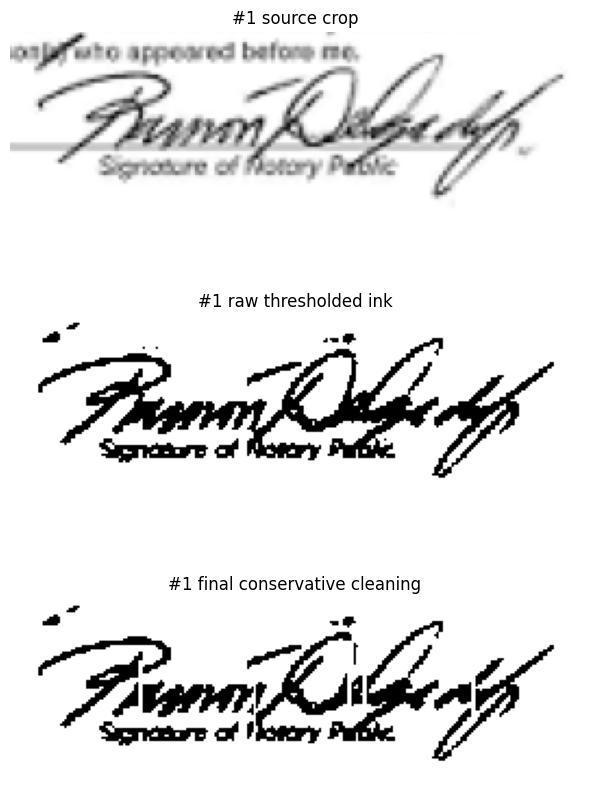

Cleaning metadata: /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/cleaning/cleaning_results.json

CELL 11 COMPLETED SUCCESSFULLY


In [14]:
# CELL 11 — Perform conservative OpenCV cleaning with rollback protection

from skimage.morphology import skeletonize

def count_connected_components(binary_foreground):
    """Count non-background 8-connected components in a boolean mask."""
    component_count, _, _, _ = cv2.connectedComponentsWithStats(
        binary_foreground.astype(np.uint8),
        connectivity=8,
    )
    return max(int(component_count) - 1, 0)


def count_skeleton_endpoints(binary_foreground):
    """Count skeleton pixels having exactly one neighbour.

    This is a structural diagnostic, not a literal count of pen strokes.
    """
    if not np.any(binary_foreground):
        return 0
    skeleton = skeletonize(binary_foreground).astype(np.uint8)
    neighbour_kernel = np.ones((3, 3), dtype=np.uint8)
    # filter2D includes the centre pixel, so a total of 2 means one neighbour.
    neighbourhood_sum = cv2.filter2D(
        skeleton, cv2.CV_16U, neighbour_kernel, borderType=cv2.BORDER_CONSTANT
    )
    return int(np.count_nonzero((skeleton == 1) & (neighbourhood_sum == 2)))


def remove_small_components(binary_foreground, minimum_area):
    """Keep connected components meeting a minimum pixel area."""
    component_count, labels, statistics, _ = cv2.connectedComponentsWithStats(
        binary_foreground.astype(np.uint8), connectivity=8
    )
    filtered = np.zeros_like(binary_foreground, dtype=bool)
    removed_component_count = 0
    for label_id in range(1, component_count):
        area = int(statistics[label_id, cv2.CC_STAT_AREA])
        if area >= minimum_area:
            filtered[labels == label_id] = True
        else:
            removed_component_count += 1
    return filtered, removed_component_count


def clean_segmented_signature(segmentation_result, cleaning_settings):
    """Return raw ink, proposed cleaning, final cleaning, and diagnostics."""
    source_rgb = segmentation_result["source_crop_rgb"]
    sam_mask = segmentation_result["mask_crop"].astype(bool)
    gray = cv2.cvtColor(source_rgb, cv2.COLOR_RGB2GRAY)

    # Otsu automatically selects a global intensity boundary. BINARY_INV makes
    # darker pixels foreground (255), matching ordinary ink on light paper.
    otsu_threshold, thresholded = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )
    raw_ink = (thresholded > 0) & sam_mask

    crop_height, crop_width = raw_ink.shape
    horizontal_length = max(3, int(round(
        crop_width * cleaning_settings["horizontal_line_kernel_fraction"]
    )))
    vertical_length = max(3, int(round(
        crop_height * cleaning_settings["vertical_line_kernel_fraction"]
    )))
    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (horizontal_length, 1)
    )
    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (1, vertical_length)
    )

    raw_ink_uint8 = raw_ink.astype(np.uint8) * 255
    horizontal_lines = cv2.morphologyEx(
        raw_ink_uint8, cv2.MORPH_OPEN, horizontal_kernel
    ) > 0
    vertical_lines = cv2.morphologyEx(
        raw_ink_uint8, cv2.MORPH_OPEN, vertical_kernel
    ) > 0
    detected_line_mask = horizontal_lines | vertical_lines

    without_lines = raw_ink & ~detected_line_mask
    proposed_cleaning, removed_small_components = remove_small_components(
        without_lines,
        int(cleaning_settings["minimum_component_area_pixels"]),
    )

    original_foreground_pixels = int(np.count_nonzero(raw_ink))
    proposed_foreground_pixels = int(np.count_nonzero(proposed_cleaning))
    removed_foreground_pixels = max(
        original_foreground_pixels - proposed_foreground_pixels, 0
    )
    removal_ratio = removed_foreground_pixels / max(original_foreground_pixels, 1)

    original_components = count_connected_components(raw_ink)
    proposed_components = count_connected_components(proposed_cleaning)
    original_endpoints = count_skeleton_endpoints(raw_ink)
    proposed_endpoints = count_skeleton_endpoints(proposed_cleaning)
    endpoint_change_ratio = abs(proposed_endpoints - original_endpoints) / max(
        original_endpoints, 1
    )

    warnings = []
    fallback_used = False
    if original_foreground_pixels == 0:
        warnings.append("No dark foreground ink was found inside the SAM mask.")
        final_cleaning = raw_ink.copy()
        fallback_used = True
    elif proposed_foreground_pixels == 0:
        warnings.append("Proposed cleaning removed all foreground; raw ink was restored.")
        final_cleaning = raw_ink.copy()
        fallback_used = True
    elif removal_ratio > cleaning_settings["maximum_foreground_removal_ratio"]:
        warnings.append(
            "Proposed cleaning removed too much foreground; raw ink was restored."
        )
        final_cleaning = raw_ink.copy()
        fallback_used = True
    else:
        final_cleaning = proposed_cleaning

    if endpoint_change_ratio > 0.50:
        warnings.append(
            "Proposed cleaning substantially changed skeleton endpoints."
        )
    if np.any(detected_line_mask):
        warnings.append(
            "Long line-like structures were detected; inspect possible signature underlines."
        )

    final_components = count_connected_components(final_cleaning)
    final_endpoints = count_skeleton_endpoints(final_cleaning)
    cleaned_binary = np.where(final_cleaning, 0, 255).astype(np.uint8)
    cleaned_colour = np.full_like(source_rgb, 255)
    cleaned_colour[final_cleaning] = source_rgb[final_cleaning]

    # A fallback is intentionally marked as not passed even though it preserves
    # the safest available pixels for downstream analysis.
    quality = {
        "passed": bool(original_foreground_pixels > 0 and not fallback_used),
        "fallback_used": fallback_used,
        "otsu_threshold": round(float(otsu_threshold), 3),
        "original_foreground_pixels": original_foreground_pixels,
        "proposed_foreground_pixels": proposed_foreground_pixels,
        "final_foreground_pixels": int(np.count_nonzero(final_cleaning)),
        "foreground_removal_ratio": round(float(removal_ratio), 6),
        "detected_line_pixels": int(np.count_nonzero(detected_line_mask)),
        "removed_small_components": int(removed_small_components),
        "original_components": original_components,
        "proposed_components": proposed_components,
        "final_components": final_components,
        "original_endpoints": original_endpoints,
        "proposed_endpoints": proposed_endpoints,
        "final_endpoints": final_endpoints,
        "endpoint_change_ratio": round(float(endpoint_change_ratio), 6),
        "warnings": warnings,
    }

    return {
        "raw_ink_mask": raw_ink,
        "detected_line_mask": detected_line_mask,
        "proposed_cleaning_mask": proposed_cleaning,
        "cleaned_ink_mask": final_cleaning,
        "cleaned_binary": cleaned_binary,
        "cleaned_colour_rgb": cleaned_colour,
        "quality": quality,
    }


CLEANING_OUTPUT_DIRECTORY = RUN_DIRECTORY / "cleaning"
CLEANING_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
CLEANING_RESULTS = []

for segmentation_result in SEGMENTATION_RESULTS:
    cleaning_result = clean_segmented_signature(
        segmentation_result, CONFIG["cleaning"]
    )
    cleaning_result["detection_number"] = segmentation_result["detection_number"]
    number = cleaning_result["detection_number"]

    raw_path = CLEANING_OUTPUT_DIRECTORY / f"candidate_{number:02d}_raw_binary.png"
    line_path = CLEANING_OUTPUT_DIRECTORY / f"candidate_{number:02d}_detected_lines.png"
    cleaned_path = CLEANING_OUTPUT_DIRECTORY / f"candidate_{number:02d}_cleaned_binary.png"
    colour_path = CLEANING_OUTPUT_DIRECTORY / f"candidate_{number:02d}_cleaned_colour.png"

    outputs_to_save = [
        (raw_path, np.where(cleaning_result["raw_ink_mask"], 0, 255).astype(np.uint8)),
        (line_path, cleaning_result["detected_line_mask"].astype(np.uint8) * 255),
        (cleaned_path, cleaning_result["cleaned_binary"]),
        (colour_path, cv2.cvtColor(cleaning_result["cleaned_colour_rgb"], cv2.COLOR_RGB2BGR)),
    ]
    for output_path, output_array in outputs_to_save:
        if not cv2.imwrite(str(output_path), output_array):
            raise OSError(f"Could not save {output_path}")

    cleaning_result["raw_binary_path"] = raw_path
    cleaning_result["detected_lines_path"] = line_path
    cleaning_result["cleaned_binary_path"] = cleaned_path
    cleaning_result["cleaned_colour_path"] = colour_path
    CLEANING_RESULTS.append(cleaning_result)

cleaning_metadata = []
array_keys = {
    "raw_ink_mask", "detected_line_mask", "proposed_cleaning_mask",
    "cleaned_ink_mask", "cleaned_binary", "cleaned_colour_rgb",
}
for result in CLEANING_RESULTS:
    cleaning_metadata.append({
        key: (str(value) if isinstance(value, Path) else value)
        for key, value in result.items() if key not in array_keys
    })

CLEANING_METADATA_PATH = CLEANING_OUTPUT_DIRECTORY / "cleaning_results.json"
CLEANING_METADATA_PATH.write_text(
    json.dumps(cleaning_metadata, indent=2), encoding="utf-8"
)

print("CLEANING SUMMARY")
print("================")
for result in CLEANING_RESULTS:
    quality = result["quality"]
    print(
        f"Candidate #{result['detection_number']}: "
        f"passed={quality['passed']}, fallback={quality['fallback_used']}, "
        f"removal={quality['foreground_removal_ratio']:.3f}, "
        f"components={quality['original_components']}→{quality['final_components']}, "
        f"endpoints={quality['original_endpoints']}→{quality['final_endpoints']}"
    )
    for warning in quality["warnings"]:
        print("   warning:", warning)

display_columns = len(CLEANING_RESULTS)
figure, axes = plt.subplots(3, display_columns, figsize=(6 * display_columns, 9), squeeze=False)
for column, (segmentation_result, cleaning_result) in enumerate(
    zip(SEGMENTATION_RESULTS, CLEANING_RESULTS)
):
    number = cleaning_result["detection_number"]
    axes[0, column].imshow(segmentation_result["source_crop_rgb"])
    axes[0, column].set_title(f"#{number} source crop")
    axes[1, column].imshow(cleaning_result["raw_ink_mask"], cmap="gray_r")
    axes[1, column].set_title(f"#{number} raw thresholded ink")
    axes[2, column].imshow(cleaning_result["cleaned_binary"], cmap="gray", vmin=0, vmax=255)
    axes[2, column].set_title(f"#{number} final conservative cleaning")
    for row in range(3):
        axes[row, column].axis("off")
figure.tight_layout()
plt.show()

print("Cleaning metadata:", CLEANING_METADATA_PATH)
print("\nCELL 11 COMPLETED SUCCESSFULLY")

## Stage 12 — Extract static-image handwriting measurements

This stage calculates raw, explainable measurements from each conservatively cleaned signature. It does not yet turn them into a manual-signing assessment. Keeping measurement separate from interpretation makes it easier to audit assumptions and replace thresholds later.

The measured groups are:

- **Ink and pressure proxies:** darkness variation, stroke-width variation, and the relationship between darkness and estimated width.
- **Texture and grain proxies:** intensity entropy, Laplacian energy, and local patch variation.
- **Curvature:** contour turning angles and sharp-turn frequency.
- **Continuity:** skeleton endpoints, junctions, connected components, and small-component area.

These are properties of a scanned raster image. They cannot recover true pen pressure, speed, stroke order, or direction. Scanner processing, compression, paper texture, resolution, thresholding, and printing can all affect the measurements.

STATIC FEATURE SUMMARY

Candidate #1
Reliable:        True
Ink/pressure:    {'mean_darkness_0_255': 120.480161, 'darkness_standard_deviation': 41.320032, 'darkness_coefficient_of_variation': 0.342961, 'stroke_width_mean_pixels': 3.348771, 'stroke_width_standard_deviation_pixels': 1.335477, 'stroke_width_coefficient_of_variation': 0.398796, 'stroke_width_darkness_correlation': 0.33069}
Texture/grain:   {'ink_intensity_entropy_normalized': 0.893029, 'laplacian_energy_mean': 62.49411, 'laplacian_energy_standard_deviation': 53.643532, 'foreground_patch_count': 133, 'patch_texture_mean': 32.302145, 'patch_texture_variation': 11.056176}
Curvature:       {'sample_count': 1780, 'mean_turning_angle_degrees': 37.030382, 'turning_angle_std_degrees': 40.002119, 'turning_angle_90th_percentile_degrees': 101.309932, 'sharp_turn_fraction_over_60_degrees': 0.226966}
Continuity:      {'connected_component_count': 21, 'skeleton_pixel_count': 982, 'endpoint_count': 62, 'junction_pixel_count': 179, 'endpoi

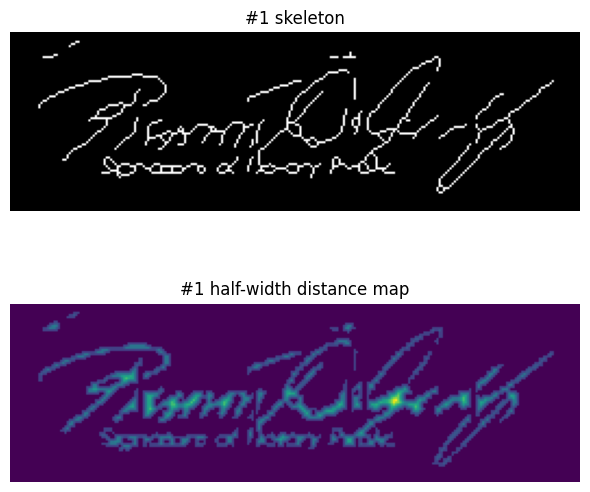

Feature metadata: /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/features/static_signature_features.json

CELL 12 COMPLETED SUCCESSFULLY


In [15]:
# CELL 12 — Measure ink, width, texture, curvature, and continuity proxies

def safe_mean(values):
    return float(np.mean(values)) if np.size(values) else 0.0


def safe_standard_deviation(values):
    return float(np.std(values)) if np.size(values) else 0.0


def safe_percentile(values, percentile):
    return float(np.percentile(values, percentile)) if np.size(values) else 0.0


def normalized_entropy_uint8(values):
    """Return 0–1 Shannon entropy for an array of 8-bit intensities."""
    if np.size(values) == 0:
        return 0.0
    histogram = np.bincount(np.asarray(values, dtype=np.uint8), minlength=256).astype(float)
    probabilities = histogram[histogram > 0] / histogram.sum()
    entropy_bits = -np.sum(probabilities * np.log2(probabilities))
    return float(entropy_bits / 8.0)


def pearson_correlation_or_zero(first_values, second_values):
    """Calculate correlation only when both samples contain variation."""
    first_values = np.asarray(first_values, dtype=float)
    second_values = np.asarray(second_values, dtype=float)
    if first_values.size < 3 or second_values.size != first_values.size:
        return 0.0
    if np.std(first_values) < 1e-8 or np.std(second_values) < 1e-8:
        return 0.0
    return float(np.corrcoef(first_values, second_values)[0, 1])


def measure_contour_curvature(binary_ink):
    """Estimate turning angles along external ink contours.

    Contour turning is a raster-shape proxy. It is not pen-tip trajectory.
    """
    contours, _ = cv2.findContours(
        binary_ink.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    turning_angles = []
    sampling_step = 3
    for contour in contours:
        points = contour[:, 0, :].astype(float)
        if len(points) < 2 * sampling_step + 1:
            continue
        # Treat every external contour as circular, matching OpenCV's closed
        # contour representation. Sampling several pixels apart reduces the
        # dominance of one-pixel staircase artifacts.
        for index in range(len(points)):
            previous_point = points[(index - sampling_step) % len(points)]
            current_point = points[index]
            next_point = points[(index + sampling_step) % len(points)]
            first_vector = current_point - previous_point
            second_vector = next_point - current_point
            first_norm = np.linalg.norm(first_vector)
            second_norm = np.linalg.norm(second_vector)
            if first_norm == 0 or second_norm == 0:
                continue
            cosine = np.clip(
                np.dot(first_vector, second_vector) / (first_norm * second_norm),
                -1.0, 1.0,
            )
            turning_angles.append(float(np.degrees(np.arccos(cosine))))

    turning_angles = np.asarray(turning_angles, dtype=float)
    return {
        "sample_count": int(turning_angles.size),
        "mean_turning_angle_degrees": round(safe_mean(turning_angles), 6),
        "turning_angle_std_degrees": round(safe_standard_deviation(turning_angles), 6),
        "turning_angle_90th_percentile_degrees": round(
            safe_percentile(turning_angles, 90), 6
        ),
        "sharp_turn_fraction_over_60_degrees": round(
            float(np.mean(turning_angles > 60.0)) if turning_angles.size else 0.0, 6
        ),
    }


def extract_static_signature_features(source_rgb, cleaned_ink, analysis_settings):
    """Extract interpretable raster measurements and reliability warnings."""
    cleaned_ink = cleaned_ink.astype(bool)
    gray = cv2.cvtColor(source_rgb, cv2.COLOR_RGB2GRAY)
    height, width = gray.shape
    foreground_pixel_count = int(np.count_nonzero(cleaned_ink))
    reliability_warnings = []

    if foreground_pixel_count < analysis_settings["minimum_foreground_pixels"]:
        reliability_warnings.append(
            "Too few foreground pixels for stable handwriting measurements."
        )
    texture_resolution_adequate = (
        width >= analysis_settings["minimum_crop_width_for_texture"]
        and height >= analysis_settings["minimum_crop_height_for_texture"]
    )
    if not texture_resolution_adequate:
        reliability_warnings.append(
            "Crop resolution is too low for dependable fine-texture measurements."
        )

    ink_intensities = gray[cleaned_ink].astype(float)
    ink_darkness = 255.0 - ink_intensities

    # Distance transform gives each foreground pixel its distance to the nearest
    # background. Twice the value sampled on the skeleton estimates local width.
    distance_transform = cv2.distanceTransform(
        cleaned_ink.astype(np.uint8), cv2.DIST_L2, 5
    )
    skeleton = skeletonize(cleaned_ink) if foreground_pixel_count else np.zeros_like(cleaned_ink)
    stroke_width_samples = 2.0 * distance_transform[skeleton]
    stroke_width_mean = safe_mean(stroke_width_samples)
    stroke_width_std = safe_standard_deviation(stroke_width_samples)
    stroke_width_cv = stroke_width_std / stroke_width_mean if stroke_width_mean > 0 else 0.0
    skeleton_darkness = (255.0 - gray.astype(float))[skeleton]
    width_darkness_correlation = pearson_correlation_or_zero(
        stroke_width_samples, skeleton_darkness
    )

    # Laplacian magnitude captures high-frequency local changes. Restricting it
    # to a one-pixel dilation around ink includes stroke edges and nearby grain.
    laplacian_magnitude = np.abs(cv2.Laplacian(gray, cv2.CV_64F))
    texture_region = cv2.dilate(
        cleaned_ink.astype(np.uint8), np.ones((3, 3), np.uint8), iterations=1
    ).astype(bool)
    laplacian_samples = laplacian_magnitude[texture_region]

    # Measure variation between small foreground-containing patches. This is
    # deliberately simple and transparent rather than a hidden learned feature.
    window = max(3, int(analysis_settings["local_texture_window_size"]))
    patch_standard_deviations = []
    for top in range(0, height, window):
        for left in range(0, width, window):
            patch_mask = cleaned_ink[top:top + window, left:left + window]
            if np.count_nonzero(patch_mask) < 3:
                continue
            patch_gray = gray[top:top + window, left:left + window]
            patch_standard_deviations.append(float(np.std(patch_gray[patch_mask])))

    # Skeleton neighbourhood totals distinguish endpoints (one neighbour) and
    # junctions (three or more). These are topology proxies after rasterization.
    skeleton_uint8 = skeleton.astype(np.uint8)
    neighbourhood_sum = cv2.filter2D(
        skeleton_uint8, cv2.CV_16U, np.ones((3, 3), np.uint8),
        borderType=cv2.BORDER_CONSTANT,
    )
    endpoint_count = int(np.count_nonzero(skeleton & (neighbourhood_sum == 2)))
    junction_count = int(np.count_nonzero(skeleton & (neighbourhood_sum >= 4)))
    skeleton_pixel_count = int(np.count_nonzero(skeleton))

    component_count, labels, statistics, _ = cv2.connectedComponentsWithStats(
        cleaned_ink.astype(np.uint8), connectivity=8
    )
    component_areas = [
        int(statistics[label, cv2.CC_STAT_AREA])
        for label in range(1, component_count)
    ]
    small_area_limit = max(4, int(round(foreground_pixel_count * 0.01)))
    small_component_area = sum(area for area in component_areas if area <= small_area_limit)

    features = {
        "input_quality": {
            "crop_width_pixels": int(width),
            "crop_height_pixels": int(height),
            "foreground_pixel_count": foreground_pixel_count,
            "texture_resolution_adequate": bool(texture_resolution_adequate),
            "measurements_reliable": len(reliability_warnings) == 0,
            "warnings": reliability_warnings,
        },
        "ink_and_pressure_proxies": {
            "mean_darkness_0_255": round(safe_mean(ink_darkness), 6),
            "darkness_standard_deviation": round(safe_standard_deviation(ink_darkness), 6),
            "darkness_coefficient_of_variation": round(
                safe_standard_deviation(ink_darkness) / max(safe_mean(ink_darkness), 1e-8), 6
            ),
            "stroke_width_mean_pixels": round(stroke_width_mean, 6),
            "stroke_width_standard_deviation_pixels": round(stroke_width_std, 6),
            "stroke_width_coefficient_of_variation": round(float(stroke_width_cv), 6),
            "stroke_width_darkness_correlation": round(width_darkness_correlation, 6),
        },
        "texture_and_grain_proxies": {
            "ink_intensity_entropy_normalized": round(
                normalized_entropy_uint8(ink_intensities), 6
            ),
            "laplacian_energy_mean": round(safe_mean(laplacian_samples), 6),
            "laplacian_energy_standard_deviation": round(
                safe_standard_deviation(laplacian_samples), 6
            ),
            "foreground_patch_count": len(patch_standard_deviations),
            "patch_texture_mean": round(safe_mean(patch_standard_deviations), 6),
            "patch_texture_variation": round(
                safe_standard_deviation(patch_standard_deviations), 6
            ),
        },
        "curvature_proxies": measure_contour_curvature(cleaned_ink),
        "continuity_proxies": {
            "connected_component_count": len(component_areas),
            "skeleton_pixel_count": skeleton_pixel_count,
            "endpoint_count": endpoint_count,
            "junction_pixel_count": junction_count,
            "endpoint_density_per_100_skeleton_pixels": round(
                100.0 * endpoint_count / max(skeleton_pixel_count, 1), 6
            ),
            "small_component_area_fraction": round(
                small_component_area / max(foreground_pixel_count, 1), 6
            ),
            "largest_component_area_fraction": round(
                max(component_areas, default=0) / max(foreground_pixel_count, 1), 6
            ),
        },
    }
    return features, skeleton, distance_transform


FEATURE_OUTPUT_DIRECTORY = RUN_DIRECTORY / "features"
FEATURE_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
SIGNATURE_FEATURE_RESULTS = []

for segmentation_result, cleaning_result in zip(SEGMENTATION_RESULTS, CLEANING_RESULTS):
    if segmentation_result["detection_number"] != cleaning_result["detection_number"]:
        raise RuntimeError("Segmentation and cleaning result ordering does not match.")

    features, skeleton, distance_transform = extract_static_signature_features(
        segmentation_result["source_crop_rgb"],
        cleaning_result["cleaned_ink_mask"],
        CONFIG["analysis"],
    )
    number = cleaning_result["detection_number"]
    skeleton_path = FEATURE_OUTPUT_DIRECTORY / f"candidate_{number:02d}_skeleton.png"
    width_map_path = FEATURE_OUTPUT_DIRECTORY / f"candidate_{number:02d}_stroke_width_map.png"

    if not cv2.imwrite(str(skeleton_path), skeleton.astype(np.uint8) * 255):
        raise OSError(f"Could not save {skeleton_path}")
    width_map_normalized = cv2.normalize(
        distance_transform, None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)
    if not cv2.imwrite(str(width_map_path), width_map_normalized):
        raise OSError(f"Could not save {width_map_path}")

    SIGNATURE_FEATURE_RESULTS.append({
        "detection_number": number,
        "features": features,
        "skeleton": skeleton,
        "distance_transform": distance_transform,
        "skeleton_path": skeleton_path,
        "stroke_width_map_path": width_map_path,
    })

feature_metadata = [{
    "detection_number": result["detection_number"],
    "features": result["features"],
    "skeleton_path": str(result["skeleton_path"]),
    "stroke_width_map_path": str(result["stroke_width_map_path"]),
} for result in SIGNATURE_FEATURE_RESULTS]

FEATURE_METADATA_PATH = FEATURE_OUTPUT_DIRECTORY / "static_signature_features.json"
FEATURE_METADATA_PATH.write_text(
    json.dumps(feature_metadata, indent=2), encoding="utf-8"
)

print("STATIC FEATURE SUMMARY")
print("======================")
for result in SIGNATURE_FEATURE_RESULTS:
    features = result["features"]
    print(f"\nCandidate #{result['detection_number']}")
    print("Reliable:       ", features["input_quality"]["measurements_reliable"])
    print("Ink/pressure:   ", features["ink_and_pressure_proxies"])
    print("Texture/grain:  ", features["texture_and_grain_proxies"])
    print("Curvature:      ", features["curvature_proxies"])
    print("Continuity:     ", features["continuity_proxies"])
    for warning in features["input_quality"]["warnings"]:
        print("   warning:", warning)

display_columns = len(SIGNATURE_FEATURE_RESULTS)
figure, axes = plt.subplots(2, display_columns, figsize=(6 * display_columns, 6), squeeze=False)
for column, result in enumerate(SIGNATURE_FEATURE_RESULTS):
    number = result["detection_number"]
    axes[0, column].imshow(result["skeleton"], cmap="gray")
    axes[0, column].set_title(f"#{number} skeleton")
    axes[1, column].imshow(result["distance_transform"], cmap="viridis")
    axes[1, column].set_title(f"#{number} half-width distance map")
    axes[0, column].axis("off")
    axes[1, column].axis("off")
figure.tight_layout()
plt.show()

print("Feature metadata:", FEATURE_METADATA_PATH)
print("\nCELL 12 COMPLETED SUCCESSFULLY")

## Stage 13 — Interpret manual-signing and reproduction indicators

This stage translates the raw measurements into reviewer-oriented indicator groups. The rules are transparent and deliberately conservative: they can identify image characteristics that are compatible with variable ink deposition, stroke-width changes, texture, curvature, and continuity, but they cannot prove that a pen physically touched the examined document.

Because the project does not currently have a labeled wet-ink-versus-reproduction calibration dataset, the thresholds below are prototype heuristics. The result is restricted to `manual_signing_indicators_present`, `possible_reproduction_indicators`, or `inconclusive`. Poor segmentation, cleaning fallback, or inadequate feature quality forces an inconclusive result.

A reproduction warning is not a forgery finding. A genuine signature can be scanned and pasted, while a forged signature can be written manually. Identity verification and forgery classification remain outside this notebook's scope.

MANUAL-SIGNING INDICATOR SUMMARY

Candidate #1
Assessment:           inconclusive
Manual score*:        0.91561
Reproduction warning*: 0.134118
Quality passed:       False
Group scores*:        {'ink_and_pressure_proxy': 0.935995, 'texture_and_grain': 0.79577, 'curvature': 0.937526, 'continuity': 0.988052, 'digital_reproduction_warning': 0.134118}
Reason: One or more signature-stage quality gates failed.

* Scores are uncalibrated prototype indicators, not probabilities.


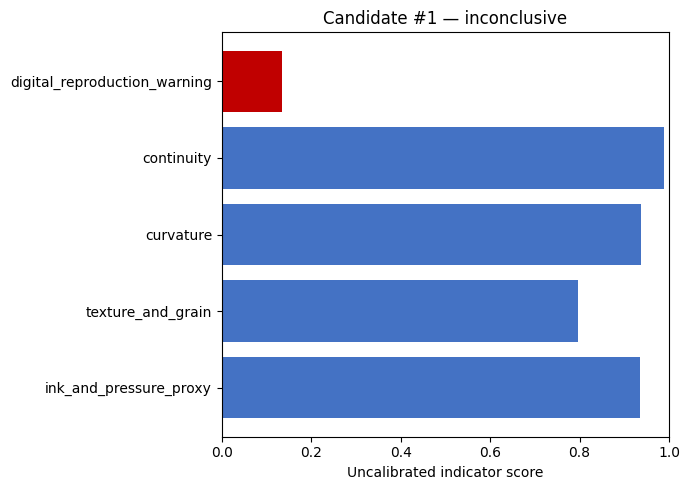

Results saved: /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/assessment/manual_signing_indicators.json
Chart saved:   /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/assessment/indicator_scores.png

CELL 13 COMPLETED SUCCESSFULLY


In [16]:
# CELL 13 — Produce quality-gated manual-signing indicator assessments

def clip_score(value):
    """Restrict a numeric indicator to the interpretable 0–1 range."""
    return float(np.clip(float(value), 0.0, 1.0))


def increasing_score(value, low, high):
    """Map values at/below low to 0 and values at/above high to 1."""
    if high <= low:
        raise ValueError("An increasing-score upper boundary must exceed its lower boundary.")
    return clip_score((float(value) - low) / (high - low))


# These limits are engineering hypotheses, not learned forensic boundaries.
# They are included in the saved report so every assessment is reproducible.
PROTOTYPE_INTERPRETATION_LIMITS = {
    "darkness_cv_low_high": [0.02, 0.20],
    "stroke_width_cv_low_high": [0.05, 0.45],
    "ink_entropy_low_high": [0.05, 0.55],
    "patch_texture_low_high": [1.0, 18.0],
    "turning_angle_std_low_high": [5.0, 45.0],
    "sharp_turn_fraction_low_high": [0.01, 0.20],
    "fragmentation_good_bad": [0.03, 0.30],
    "manual_indicator_minimum": 0.60,
    "reproduction_warning_minimum": 0.70,
}


def interpret_static_features(feature_result, segmentation_result, cleaning_result):
    """Fuse transparent heuristic indicators with strict quality gates."""
    features = feature_result["features"]
    ink = features["ink_and_pressure_proxies"]
    texture = features["texture_and_grain_proxies"]
    curvature = features["curvature_proxies"]
    continuity = features["continuity_proxies"]
    limits = PROTOTYPE_INTERPRETATION_LIMITS

    darkness_variation = increasing_score(
        ink["darkness_coefficient_of_variation"], *limits["darkness_cv_low_high"]
    )
    width_variation = increasing_score(
        ink["stroke_width_coefficient_of_variation"],
        *limits["stroke_width_cv_low_high"],
    )
    ink_pressure_score = float(np.mean([darkness_variation, width_variation]))

    entropy_score = increasing_score(
        texture["ink_intensity_entropy_normalized"],
        *limits["ink_entropy_low_high"],
    )
    patch_texture_score = increasing_score(
        texture["patch_texture_variation"],
        *limits["patch_texture_low_high"],
    )
    texture_score = float(np.mean([entropy_score, patch_texture_score]))

    curvature_variation = increasing_score(
        curvature["turning_angle_std_degrees"],
        *limits["turning_angle_std_low_high"],
    )
    sharp_turn_score = increasing_score(
        curvature["sharp_turn_fraction_over_60_degrees"],
        *limits["sharp_turn_fraction_low_high"],
    )
    curvature_score = float(np.mean([curvature_variation, sharp_turn_score]))

    fragmentation = continuity["small_component_area_fraction"]
    fragmentation_penalty = increasing_score(
        fragmentation, *limits["fragmentation_good_bad"]
    )
    foreground_exists = 1.0 if features["input_quality"]["foreground_pixel_count"] > 0 else 0.0
    skeleton_exists = 1.0 if continuity["skeleton_pixel_count"] > 0 else 0.0
    continuity_score = float(np.mean([
        1.0 - fragmentation_penalty, foreground_exists, skeleton_exists
    ]))

    group_scores = {
        "ink_and_pressure_proxy": round(ink_pressure_score, 6),
        "texture_and_grain": round(texture_score, 6),
        "curvature": round(curvature_score, 6),
        "continuity": round(continuity_score, 6),
    }

    # Uniform darkness, width, and texture increase a reproduction warning.
    # This warning remains weak evidence because clean scans can also be uniform.
    reproduction_warning_score = float(np.mean([
        1.0 - darkness_variation,
        1.0 - width_variation,
        1.0 - entropy_score,
        1.0 - patch_texture_score,
    ]))
    group_scores["digital_reproduction_warning"] = round(
        reproduction_warning_score, 6
    )

    # The configured digital-reproduction weight is a penalty rather than a
    # positive manual indicator. Renormalize the four positive group weights.
    configured_weights = CONFIG["analysis"]["indicator_weights"]
    positive_group_names = [
        "ink_and_pressure_proxy", "texture_and_grain",
        "curvature", "continuity",
    ]
    positive_weight_total = sum(configured_weights[name] for name in positive_group_names)
    manual_indicator_score = sum(
        group_scores[name] * configured_weights[name] / positive_weight_total
        for name in positive_group_names
    )

    quality_checks = {
        "document_quality": bool(DOCUMENT_QUALITY["passed"]),
        "detection_quality": bool(
            next(
                detection for detection in ACCEPTED_DETECTIONS
                if detection["detection_number"] == feature_result["detection_number"]
            )["quality"]["passed"]
        ),
        "segmentation_quality": bool(segmentation_result["quality"]["passed"]),
        "cleaning_without_fallback": not bool(cleaning_result["quality"]["fallback_used"]),
        "feature_measurements_reliable": bool(
            features["input_quality"]["measurements_reliable"]
        ),
    }
    # Document warnings alone do not force failure, because a dimension warning
    # may coexist with an adequate signature crop. The signature-stage checks do.
    decisive_quality_passed = all([
        quality_checks["detection_quality"],
        quality_checks["segmentation_quality"],
        quality_checks["cleaning_without_fallback"],
        quality_checks["feature_measurements_reliable"],
    ])

    reasons = []
    warnings = []
    if not decisive_quality_passed:
        assessment = "inconclusive"
        reasons.append("One or more signature-stage quality gates failed.")
    elif (
        manual_indicator_score >= limits["manual_indicator_minimum"]
        and reproduction_warning_score < limits["reproduction_warning_minimum"]
    ):
        assessment = "manual_signing_indicators_present"
        reasons.append(
            "Several static-image variability and continuity indicators are present."
        )
    elif (
        reproduction_warning_score >= limits["reproduction_warning_minimum"]
        and manual_indicator_score < limits["manual_indicator_minimum"]
    ):
        assessment = "possible_reproduction_indicators"
        reasons.append(
            "The extracted ink, width, and texture measurements are unusually uniform."
        )
    else:
        assessment = "inconclusive"
        reasons.append("Manual-signing and reproduction indicators do not separate clearly.")

    if not quality_checks["document_quality"]:
        warnings.extend(DOCUMENT_QUALITY["warnings"])
    warnings.extend(segmentation_result["quality"]["warnings"])
    warnings.extend(cleaning_result["quality"]["warnings"])
    warnings.extend(features["input_quality"]["warnings"])
    warnings.append(
        "Prototype thresholds are not calibrated on wet-ink versus reproduction data."
    )

    recommended_checks = [
        "Inspect the original paper under magnification and oblique lighting.",
        "Examine indentation evidence and ink deposition beyond the raster image.",
        "Inspect the source PDF for a separate signature image or reusable object layer.",
        "Compare for pixel-identical or near-identical signatures across related documents.",
        "Acquire a 600-DPI or higher lossless scan when fine texture matters.",
        "Use a qualified forensic document examiner for consequential decisions.",
    ]

    return {
        "detection_number": feature_result["detection_number"],
        "assessment": assessment,
        "manual_indicator_score_uncalibrated": round(float(manual_indicator_score), 6),
        "reproduction_warning_score_uncalibrated": round(
            float(reproduction_warning_score), 6
        ),
        "group_scores_uncalibrated": group_scores,
        "quality_checks": quality_checks,
        "decisive_quality_passed": decisive_quality_passed,
        "reasons": reasons,
        "warnings": list(dict.fromkeys(warnings)),
        "recommended_further_checks": recommended_checks,
        "prototype_limits": limits,
        "disclaimer": (
            "Static-image indicators cannot establish physical pen contact, "
            "identity, genuineness, forgery, or legal validity."
        ),
    }


MANUAL_SIGNING_RESULTS = []
for feature_result, segmentation_result, cleaning_result in zip(
    SIGNATURE_FEATURE_RESULTS, SEGMENTATION_RESULTS, CLEANING_RESULTS
):
    result_numbers = {
        feature_result["detection_number"],
        segmentation_result["detection_number"],
        cleaning_result["detection_number"],
    }
    if len(result_numbers) != 1:
        raise RuntimeError("Feature, segmentation, and cleaning candidates do not align.")
    MANUAL_SIGNING_RESULTS.append(
        interpret_static_features(feature_result, segmentation_result, cleaning_result)
    )

ASSESSMENT_OUTPUT_DIRECTORY = RUN_DIRECTORY / "assessment"
ASSESSMENT_OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
MANUAL_SIGNING_RESULTS_PATH = ASSESSMENT_OUTPUT_DIRECTORY / "manual_signing_indicators.json"
MANUAL_SIGNING_RESULTS_PATH.write_text(
    json.dumps(MANUAL_SIGNING_RESULTS, indent=2), encoding="utf-8"
)

print("MANUAL-SIGNING INDICATOR SUMMARY")
print("================================")
for result in MANUAL_SIGNING_RESULTS:
    print(f"\nCandidate #{result['detection_number']}")
    print("Assessment:          ", result["assessment"])
    print("Manual score*:       ", result["manual_indicator_score_uncalibrated"])
    print("Reproduction warning*:", result["reproduction_warning_score_uncalibrated"])
    print("Quality passed:      ", result["decisive_quality_passed"])
    print("Group scores*:       ", result["group_scores_uncalibrated"])
    for reason in result["reasons"]:
        print("Reason:", reason)
    for warning in result["warnings"]:
        print("Warning:", warning)
print("\n* Scores are uncalibrated prototype indicators, not probabilities.")

# A bar chart exposes the relationship between evidence groups rather than
# presenting only one opaque aggregate number.
figure, axes = plt.subplots(
    1, len(MANUAL_SIGNING_RESULTS),
    figsize=(7 * len(MANUAL_SIGNING_RESULTS), 5),
    squeeze=False,
)
for column, result in enumerate(MANUAL_SIGNING_RESULTS):
    names = list(result["group_scores_uncalibrated"].keys())
    values = [result["group_scores_uncalibrated"][name] for name in names]
    axes[0, column].barh(names, values, color=["#4472C4"] * 4 + ["#C00000"])
    axes[0, column].set_xlim(0, 1)
    axes[0, column].set_xlabel("Uncalibrated indicator score")
    axes[0, column].set_title(
        f"Candidate #{result['detection_number']} — {result['assessment']}"
    )
figure.tight_layout()
ASSESSMENT_CHART_PATH = ASSESSMENT_OUTPUT_DIRECTORY / "indicator_scores.png"
figure.savefig(ASSESSMENT_CHART_PATH, dpi=160, bbox_inches="tight")
plt.show()

print("Results saved:", MANUAL_SIGNING_RESULTS_PATH)
print("Chart saved:  ", ASSESSMENT_CHART_PATH)
print("\nCELL 13 COMPLETED SUCCESSFULLY")

## Stage 14 — Create the final evidence report and artifact manifest

This final stage combines document quality, YOLO detection, human selection, SAM segmentation, OpenCV cleaning, raw feature measurements, and the quality-gated indicator assessment into one local report.

Three persistent artifacts are created in the current Google Drive run directory:

- `final_summary.json` for downstream software.
- `review_report.md` for a human reviewer.
- `artifact_manifest.json` containing file sizes and SHA-256 checksums.

The report is generated deterministically from local results. No images, paths, measurements, or other document information are sent to an external reporting service.

In [17]:
# CELL 14 — Save the final local report, summary, and artifact manifest

from IPython.display import Markdown, display

def markdown_escape(value):
    """Escape characters that would break a simple Markdown table cell."""
    return str(value).replace("|", "\\|").replace("\n", "<br>")


# Keep the final JSON summary compact and free of image arrays. Detailed stage
# metadata remains available in the JSON files created by earlier cells.
FINAL_SUMMARY = {
    "run_id": RUN_ID,
    "source_document": {
        "original_filename": INPUT_METADATA["original_filename"],
        "stored_path": INPUT_METADATA["stored_path"],
        "selected_page_number": PAGE_NUMBER,
        "page_count": DOCUMENT_PAGE_COUNT,
    },
    "document_quality": DOCUMENT_QUALITY,
    "yolo_model": {
        "repository": YOLO_MODEL_METADATA["repository"],
        "sha256": YOLO_MODEL_METADATA["sha256"],
        "class_names": YOLO_CLASS_NAMES,
    },
    "sam_model": SAM_MODEL_METADATA,
    "detection": {
        "candidate_count": len(SIGNATURE_DETECTIONS),
        "accepted_detection_numbers": sorted(ACCEPTED_DETECTION_NUMBERS),
        "accepted_count": len(ACCEPTED_DETECTIONS),
    },
    "candidate_results": [],
    "scope": {
        "identity_verification_performed": False,
        "forgery_classification_performed": False,
        "bhsig260_used": False,
        "cedar_used": False,
        "external_reporting_service_used": False,
    },
    "disclaimer": (
        "Static-image indicators cannot establish physical pen contact, "
        "identity, genuineness, forgery, or legal validity."
    ),
}

for detection, segmentation, cleaning, feature, assessment in zip(
    ACCEPTED_DETECTIONS, SEGMENTATION_RESULTS, CLEANING_RESULTS,
    SIGNATURE_FEATURE_RESULTS, MANUAL_SIGNING_RESULTS,
):
    candidate_numbers = {
        detection["detection_number"], segmentation["detection_number"],
        cleaning["detection_number"], feature["detection_number"],
        assessment["detection_number"],
    }
    if len(candidate_numbers) != 1:
        raise RuntimeError("Final candidate results do not align by detection number.")
    FINAL_SUMMARY["candidate_results"].append({
        "detection_number": detection["detection_number"],
        "detection_confidence": detection["confidence"],
        "detection_box_xyxy": detection["bbox_xyxy"],
        "detection_quality": detection["quality"],
        "segmentation_quality": segmentation["quality"],
        "cleaning_quality": cleaning["quality"],
        "static_features": feature["features"],
        "indicator_assessment": assessment,
        "artifacts": {
            "yolo_crop": str(detection["crop_path"]),
            "sam_mask": str(segmentation["mask_path"]),
            "sam_segmented_crop": str(segmentation["segmented_path"]),
            "sam_overlay": str(segmentation["overlay_path"]),
            "cleaned_binary": str(cleaning["cleaned_binary_path"]),
            "cleaned_colour": str(cleaning["cleaned_colour_path"]),
            "skeleton": str(feature["skeleton_path"]),
            "stroke_width_map": str(feature["stroke_width_map_path"]),
        },
    })

FINAL_SUMMARY_PATH = RUN_DIRECTORY / "final_summary.json"
FINAL_SUMMARY_PATH.write_text(
    json.dumps(FINAL_SUMMARY, indent=2), encoding="utf-8"
)

# Assemble Markdown line by line to keep the report deterministic and easy to
# audit. Relative image paths work when the report is viewed from its run folder.
report_lines = [
    "# Signature Extraction and Static-Image Indicator Report",
    "",
    f"**Run ID:** `{RUN_ID}`  ",
    f"**Input:** `{markdown_escape(INPUT_METADATA['original_filename'])}`  ",
    f"**Selected page:** {PAGE_NUMBER} of {DOCUMENT_PAGE_COUNT} page(s)  ",
    f"**Accepted signatures:** {len(ACCEPTED_DETECTIONS)}",
    "",
    "## Scope",
    "",
    "This run localized signatures with YOLO, segmented accepted candidates with SAM, cleaned them conservatively with OpenCV, and measured static-image manual-signing and reproduction indicators. It did not verify writer identity or classify genuineness or forgery.",
    "",
    "## Document quality",
    "",
    f"- Passed all acquisition checks: **{DOCUMENT_QUALITY['passed']}**",
]
for name, value in DOCUMENT_QUALITY["measurements"].items():
    report_lines.append(f"- {name}: `{value}`")
for warning in DOCUMENT_QUALITY["warnings"]:
    report_lines.append(f"- Warning: {markdown_escape(warning)}")

report_lines.extend([
    "",
    "## YOLO detection",
    "",
    f"- Candidates detected: **{len(SIGNATURE_DETECTIONS)}**",
    f"- Accepted detection numbers: **{sorted(ACCEPTED_DETECTION_NUMBERS)}**",
    f"- Model repository: `{YOLO_MODEL_METADATA['repository']}`",
    f"- Model SHA-256: `{YOLO_MODEL_METADATA['sha256']}`",
    "",
    "![YOLO annotated page](detections/yolo_annotated_page.png)",
])

for candidate in FINAL_SUMMARY["candidate_results"]:
    number = candidate["detection_number"]
    assessment = candidate["indicator_assessment"]
    features = candidate["static_features"]
    report_lines.extend([
        "",
        f"## Candidate {number}",
        "",
        f"- YOLO confidence: `{candidate['detection_confidence']:.6f}`",
        f"- Bounding box: `{candidate['detection_box_xyxy']}`",
        f"- SAM quality passed: **{candidate['segmentation_quality']['passed']}**",
        f"- Cleaning quality passed: **{candidate['cleaning_quality']['passed']}**",
        f"- Assessment: **{assessment['assessment']}**",
        f"- Manual indicator score (uncalibrated): `{assessment['manual_indicator_score_uncalibrated']}`",
        f"- Reproduction warning score (uncalibrated): `{assessment['reproduction_warning_score_uncalibrated']}`",
        "",
        f"![Candidate {number} segmented](segmentation/candidate_{number:02d}_segmented.png)",
        "",
        f"![Candidate {number} cleaned](cleaning/candidate_{number:02d}_cleaned_colour.png)",
        "",
        "### Indicator groups",
        "",
        "| Group | Uncalibrated score |",
        "|---|---:|",
    ])
    for group_name, score in assessment["group_scores_uncalibrated"].items():
        report_lines.append(f"| {markdown_escape(group_name)} | {score:.6f} |")
    report_lines.extend(["", "### Reasons and warnings", ""])
    for reason in assessment["reasons"]:
        report_lines.append(f"- Reason: {markdown_escape(reason)}")
    for warning in assessment["warnings"]:
        report_lines.append(f"- Warning: {markdown_escape(warning)}")

recommended_checks = (
    MANUAL_SIGNING_RESULTS[0]["recommended_further_checks"]
    if MANUAL_SIGNING_RESULTS else []
)
report_lines.extend(["", "## Recommended further checks", ""])
for check in recommended_checks:
    report_lines.append(f"- {markdown_escape(check)}")
report_lines.extend([
    "",
    "## Limitation",
    "",
    FINAL_SUMMARY["disclaimer"],
    "The numeric scores are uncalibrated engineering indicators, not probabilities.",
])

REVIEW_REPORT_PATH = RUN_DIRECTORY / "review_report.md"
REVIEW_REPORT_PATH.write_text("\n".join(report_lines), encoding="utf-8")

# Create the manifest last so it covers every report and stage artifact. Exclude
# the manifest itself because its checksum would change when written.
ARTIFACT_MANIFEST_PATH = RUN_DIRECTORY / "artifact_manifest.json"
manifest_records = []
for artifact_path in sorted(RUN_DIRECTORY.rglob("*")):
    if not artifact_path.is_file() or artifact_path == ARTIFACT_MANIFEST_PATH:
        continue
    artifact_hasher = hashlib.sha256()
    with artifact_path.open("rb") as artifact_file:
        for chunk in iter(lambda: artifact_file.read(1024 * 1024), b""):
            artifact_hasher.update(chunk)
    manifest_records.append({
        "relative_path": str(artifact_path.relative_to(RUN_DIRECTORY)),
        "size_bytes": artifact_path.stat().st_size,
        "sha256": artifact_hasher.hexdigest(),
    })
ARTIFACT_MANIFEST_PATH.write_text(
    json.dumps({
        "run_id": RUN_ID,
        "artifact_count": len(manifest_records),
        "artifacts": manifest_records,
    }, indent=2),
    encoding="utf-8",
)

print("FINAL RUN SUMMARY")
print("=================")
print("Run directory:    ", RUN_DIRECTORY)
print("Accepted results: ", len(FINAL_SUMMARY["candidate_results"]))
for result in MANUAL_SIGNING_RESULTS:
    print(f"Candidate #{result['detection_number']}: {result['assessment']}")
print("Summary JSON:     ", FINAL_SUMMARY_PATH)
print("Markdown report:  ", REVIEW_REPORT_PATH)
print("Artifact manifest:", ARTIFACT_MANIFEST_PATH)
print("Artifacts hashed: ", len(manifest_records))

display(Markdown(REVIEW_REPORT_PATH.read_text(encoding="utf-8")))
print("\nCELL 14 COMPLETED SUCCESSFULLY — PIPELINE COMPLETE")

FINAL RUN SUMMARY
Run directory:     /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z
Accepted results:  1
Candidate #1: inconclusive
Summary JSON:      /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/final_summary.json
Markdown report:   /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/review_report.md
Artifact manifest: /content/drive/MyDrive/Signature-Analysis-Project/outputs/runs/20260811T153618_886744Z/artifact_manifest.json
Artifacts hashed:  30


# Signature Extraction and Static-Image Indicator Report

**Run ID:** `20260811T153618_886744Z`  
**Input:** `Test Signed Form.png`  
**Selected page:** 0 of 1 page(s)  
**Accepted signatures:** 1

## Scope

This run localized signatures with YOLO, segmented accepted candidates with SAM, cleaned them conservatively with OpenCV, and measured static-image manual-signing and reproduction indicators. It did not verify writer identity or classify genuineness or forgery.

## Document quality

- Passed all acquisition checks: **True**
- width_pixels: `1534`
- height_pixels: `985`
- mean_brightness_0_255: `243.867`
- contrast_standard_deviation: `31.121`
- laplacian_variance: `959.211`

## YOLO detection

- Candidates detected: **5**
- Accepted detection numbers: **[1]**
- Model repository: `tech4humans/yolov8s-signature-detector`
- Model SHA-256: `789580c242ac6f2543b4c09f083ca8c4ef6f1c598359bd2395febfcbcce99363`

![YOLO annotated page](detections/yolo_annotated_page.png)

## Candidate 1

- YOLO confidence: `0.844806`
- Bounding box: `[1243, 610, 1489, 676]`
- SAM quality passed: **False**
- Cleaning quality passed: **True**
- Assessment: **inconclusive**
- Manual indicator score (uncalibrated): `0.91561`
- Reproduction warning score (uncalibrated): `0.134118`

![Candidate 1 segmented](segmentation/candidate_01_segmented.png)

![Candidate 1 cleaned](cleaning/candidate_01_cleaned_colour.png)

### Indicator groups

| Group | Uncalibrated score |
|---|---:|
| ink_and_pressure_proxy | 0.935995 |
| texture_and_grain | 0.795770 |
| curvature | 0.937526 |
| continuity | 0.988052 |
| digital_reproduction_warning | 0.134118 |

### Reasons and warnings

- Reason: One or more signature-stage quality gates failed.
- Warning: SAM mask touches the YOLO-box boundary and may be incomplete.
- Warning: Long line-like structures were detected; inspect possible signature underlines.
- Warning: Prototype thresholds are not calibrated on wet-ink versus reproduction data.

## Recommended further checks

- Inspect the original paper under magnification and oblique lighting.
- Examine indentation evidence and ink deposition beyond the raster image.
- Inspect the source PDF for a separate signature image or reusable object layer.
- Compare for pixel-identical or near-identical signatures across related documents.
- Acquire a 600-DPI or higher lossless scan when fine texture matters.
- Use a qualified forensic document examiner for consequential decisions.

## Limitation

Static-image indicators cannot establish physical pen contact, identity, genuineness, forgery, or legal validity.
The numeric scores are uncalibrated engineering indicators, not probabilities.


CELL 14 COMPLETED SUCCESSFULLY — PIPELINE COMPLETE
